In [ ]:
import cospar as cs
import pandas as pd
import os
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import mosaiclineage as mosaic
import mosaiclineage.help_functions as hf
import mosaiclineage.plot_scripts as mosaic_pl
import mosaiclineage.DARLIN as mosaic_dar
import warnings
warnings.filterwarnings("ignore")

## setting cospar
cs.logging.print_version()
cs.settings.verbosity = 0
cs.settings.set_figure_params(format='pdf', figsize=[4,3.5], dpi=75, fontsize=14, pointsize=2)

%matplotlib inline

## notebook specific parameters
target_sample = 'CA'
read_cutoff = 3        # Read cutoff
min_clone_size = 2     # Clone size cutoff
max_rep_N = 0          # Mouse replicate number cutoff
frequency_cutoff = 0.1 # Allele probability cutoff
BC_complexity = 4      # Barcode complexity cutoff
norm_method = ''       
save_data_des = f'_freqCutoff{frequency_cutoff}{norm_method}'

## setup folders 
root_path = '/scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3'   # <-- change if needed
ref_dir = mosaic.settings.ref_dir
root_analysis_path = os.path.join(root_path, 'CA')
data_path = os.path.join(root_analysis_path, 'DARLIN', f'results_cutoff_override_{read_cutoff}')

if os.path.exists(root_path):
    data_analysis_path = os.path.join(root_analysis_path, 'data')   
    paper_figure_path = os.path.join(root_analysis_path, 'figure')    
    os.makedirs(data_analysis_path, exist_ok=True)
    os.makedirs(paper_figure_path, exist_ok=True)
    cs.settings.data_path = data_analysis_path
    cs.settings.figure_path = paper_figure_path

## your selected samples
sample_names = [
    "DRG-L1-CA_S1_L001",
    "DA-CA_S11_L001",
    "DRG-R1-CA_S3_L001",
    "Heart-CA_S9_L001",
    "SG-L1-CA_S5_L001",
    "SG-R1-CA_S7_L001",
    "SG-R2-CA_S8_L001"
]

print("Samples:", sample_names)
print("Data path:", data_path)


/uufs/chpc.utah.edu/common/HIPAA/u6069192/.conda/envs/DARLIN_analysis/lib/python3.8/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Running cospar 0.3.3 (python 3.8.20) on 2025-10-08 10:05.
Samples: ['DRG-L1-CA_S1_L001', 'DA-CA_S11_L001', 'DRG-R1-CA_S3_L001', 'Heart-CA_S9_L001', 'SG-L1-CA_S5_L001', 'SG-R1-CA_S7_L001', 'SG-R2-CA_S8_L001']
Data path: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/CA/DARLIN/results_cutoff_override_3


In [2]:
def apply_frequency_and_complexity_cutoff_to_get_HQ_alleles(df_merge, BC_complexity, frequency_cutoff):
    # Generate single-allele CARLIN table
    df_sc_CARLIN = hf.generate_sc_CARLIN_from_CARLIN_output(df_merge)
    
    # Count number of mutations per allele
    df_sc_CARLIN['mutation_N'] = df_sc_CARLIN['allele'].apply(lambda x: len(x.split(',')))
    
    # Remove "locus_" prefix if present
    df_sc_CARLIN['allele'] = df_sc_CARLIN['allele'].apply(lambda x: x[6:] if x.startswith('locus_') else x)
    
    # Calculate total insertion length for each allele
    ins_per_allele, del_per_allele = hf.mutations_length_per_allele_ins_del(df_sc_CARLIN)
    df_sc_CARLIN['insertion_length'] = [np.sum(x) for x in ins_per_allele]
    
    # Filter for high-quality alleles based on frequency and complexity cutoffs
    df_sc_CARLIN_HQ_raw = mosaic_dar.filter_high_quality_single_alleles(
        df_sc_CARLIN,
        normalized_count_cutoff=frequency_cutoff,
        sample_count_cutoff=max_rep_N
    )
    
    # Keep alleles that meet the barcode complexity requirement
    df_sc_CARLIN_HQ = df_sc_CARLIN_HQ_raw[
        (df_sc_CARLIN_HQ_raw['mutation_N'] + df_sc_CARLIN_HQ_raw['insertion_length']) >= BC_complexity
    ]
    
    return df_sc_CARLIN_HQ


def pvalue_estimation(df_tmp, key_1, key_2):
    from scipy.stats import ttest_ind
    var_list = list(df_tmp[key_1].unique())
    name_list = []
    pvalue_list = []
    
    for i in range(len(var_list)):
        for j in range(i + 1, len(var_list)):
            test_data_0 = df_tmp[df_tmp[key_1] == var_list[i]][key_2].values
            test_data_1 = df_tmp[df_tmp[key_1] == var_list[j]][key_2].values
            stat, pvalue = ttest_ind(test_data_0, test_data_1)
            name_list.append((var_list[i], var_list[j]))
            pvalue_list.append(pvalue)
            
    return pd.DataFrame({'name': name_list, 'pvalue': pvalue_list})


# === No renaming needed for your CA samples ===
def rename_LF(x):
    return x


ERROR: XMLRPC request failed [code: -32500]
RuntimeError: PyPI no longer supports 'pip search' (or XML-RPC search). Please use https://pypi.org/search (via a browser) instead. See https://warehouse.pypa.io/api-reference/xml-rpc.html#deprecated-methods for more information.


In [ ]:
#Config parameters

In [59]:
# === Metadata setup for your CA samples ===

mouse_list = ['CA']
stage_order = ['Adult']

map_mouse_to_SampleList = {'CA': 'tissues'}
stage_map_new = {'Adult': 'Adult-1'}
mouse_map = {'CA': 'Adult'}
mouse_map_2 = {'CA': 'Induce at adult (CA samples)'}

# Tissue colors for your seven samples
tissue_colors = dict(zip(
    ['DRG-L1', 'DRG-R1', 'SG-L1', 'SG-R1', 'SG-R2', 'DA', 'Heart'],
    sns.color_palette("tab10", 7).as_hex()
))

# Placeholder for cell type color map (kept same variable name for compatibility)
celltype_colors = {'Tissue': '#66c2a5'}

# Y-axis limits, titles, and stage IDs
ylim_map = {'CA': 1000}
title_map = {'Adult': 'DARLIN CA Samples'}
stage_id_map = dict(zip(stage_order, np.arange(len(stage_order))))

# Generate sample lists (keep same naming and structure as tutorial)
SampleList_RAW_0 = [
    "DRG-L1-CA_S1_L001",
    "DA-CA_S11_L001",
    "DRG-R1-CA_S3_L001",
    "Heart-CA_S9_L001",
    "SG-L1-CA_S5_L001",
    "SG-R1-CA_S7_L001",
    "SG-R2-CA_S8_L001"
]

SampleList_RAW_noSkull_0 = SampleList_RAW_0.copy()

print("Samples:", SampleList_RAW_0)
print("Tissue color map:", tissue_colors)
print("Stage ID map:", stage_id_map)


Samples: ['DRG-L1-CA_S1_L001', 'DA-CA_S11_L001', 'DRG-R1-CA_S3_L001', 'Heart-CA_S9_L001', 'SG-L1-CA_S5_L001', 'SG-R1-CA_S7_L001', 'SG-R2-CA_S8_L001']
Tissue color map: {'DRG-L1': '#1f77b4', 'DRG-R1': '#ff7f0e', 'SG-L1': '#2ca02c', 'SG-R1': '#d62728', 'SG-R2': '#9467bd', 'DA': '#8c564b', 'Heart': '#e377c2'}
Stage ID map: {'Adult': 0}


In [ ]:
#Load data and save to csv file

In [ ]:
locus = 'TA'

# === Load allele reference table ===
df_ref = pd.read_csv(f'{ref_dir}/reference_merged_alleles_{locus}.csv')
df_ref['invalid_alleles'] = (
    (df_ref['normalized_count'] >= frequency_cutoff) |
    (df_ref['sample_count'] > max_rep_N)
)


for read_cutoff_tmp in [3]:  # Read cutoff
    for mouse in mouse_list:  # mouse_list = ['CA']
        print(mouse)

        # Your result directory already points to results_cutoff_override_3
        data_path_tmp = root_path
        merge_all_path = f'{data_path_tmp}/merge_all'
        os.makedirs(merge_all_path, exist_ok=True)

        # Use all 7 CA samples
        SampleList_RAW = [
            "DRG-L1-CA_S1_L001",
            "DA-CA_S11_L001",
            "DRG-R1-CA_S3_L001",
            "Heart-CA_S9_L001",
            "SG-L1-CA_S5_L001",
            "SG-R1-CA_S7_L001",
            "SG-R2-CA_S8_L001"
        ]

        # === Extract the allele table ===
        df_all = mosaic.DARLIN.extract_CARLIN_info(
            data_path_tmp,
            SampleList_RAW,
            sample_name_format='CA'  # your naming pattern
        )

        # === Merge with reference allele frequencies ===
        df_all = df_all.merge(df_ref, on="allele", how="left")

        # === Save the merged allele data ===
        output_file = f'{merge_all_path}/df_allele_all_{mouse}_{save_data_des}.csv'
        df_all.to_csv(output_file, index=False)

        print(f"Saved: {output_file}")
        display(df_all.head(10))


CA
Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_CA__freqCutoff0.1.csv


,allele,UMI_count,sample,mouse,CB,CB_N,CARLIN,CARLIN_length,clone_size,observed_count,sample_count,normalized_count,smoothed_homoplasy,sample_id,invalid_alleles
0,23_268del,1394,DRG-L1-CA_S1_L001,DRG-L1-CA_S1_L001,"AAAACGGATGCA,AAAATTACCGTG,AAACACGTCGAA,AAACACT...",1394,CGCCGGACTGCACGACAGTCGATGGGAGCT,30,5285,168.0,4.0,0.000148,0.633122,"['LL584', 'LL583', 'LL762_E9', 'LL638']",True
1,23_268del,602,DA-CA_S11_L001,DA-CA_S11_L001,"AAAAAAATGAGG,AAAGGAGCGTAT,AAAGGGGCGAAA,AAAGTTT...",602,CGCCGGACTGCACGACAGTCGATGGGAGCT,30,5285,168.0,4.0,0.000148,0.633122,"['LL584', 'LL583', 'LL762_E9', 'LL638']",True
2,23_268del,1298,DRG-R1-CA_S3_L001,DRG-R1-CA_S3_L001,"AAAAAAGCCATT,AAAAAGGTTTGA,AAAACGCCAGGG,AAAACGT...",1298,CGCCGGACTGCACGACAGTCGATGGGAGCT,30,5285,168.0,4.0,0.000148,0.633122,"['LL584', 'LL583', 'LL762_E9', 'LL638']",True
3,23_268del,1267,Heart-CA_S9_L001,Heart-CA_S9_L001,"AAAACTGTGCTT,AAAAGATACTAT,AAAAGCGGGGAA,AAAATGT...",1267,CGCCGGACTGCACGACAGTCGATGGGAGCT,30,5285,168.0,4.0,0.000148,0.633122,"['LL584', 'LL583', 'LL762_E9', 'LL638']",True
4,23_268del,239,SG-L1-CA_S5_L001,SG-L1-CA_S5_L001,"AAAAGTTTGGTG,AAACCGGGTTGA,AAATATGACCCA,AACTAAT...",239,CGCCGGACTGCACGACAGTCGATGGGAGCT,30,5285,168.0,4.0,0.000148,0.633122,"['LL584', 'LL583', 'LL762_E9', 'LL638']",True
5,23_268del,52,SG-R1-CA_S7_L001,SG-R1-CA_S7_L001,"AAACAATCACCC,AAGTCGGTAATT,AATGCTCTACGG,ACCATTC...",52,CGCCGGACTGCACGACAGTCGATGGGAGCT,30,5285,168.0,4.0,0.000148,0.633122,"['LL584', 'LL583', 'LL762_E9', 'LL638']",True
6,23_268del,433,SG-R2-CA_S8_L001,SG-R2-CA_S8_L001,"AAAATTCAGGAA,AAAGCTAGCTTT,AAATTCGGTTTG,AAATTTA...",433,CGCCGGACTGCACGACAGTCGATGGGAGCT,30,5285,168.0,4.0,0.000148,0.633122,"['LL584', 'LL583', 'LL762_E9', 'LL638']",True
7,23_264del,394,DRG-L1-CA_S1_L001,DRG-L1-CA_S1_L001,"AAAAAATTGGTC,AAAAGAGGATAG,AAACGGATCATC,AAAGTTT...",394,CGCCGGACTGCACGACAGTCGAACGATGGGAGCT,34,1644,NaN,NaN,NaN,NaN,NaN,NaN
8,23_264del,151,DA-CA_S11_L001,DA-CA_S11_L001,"AAAATTTCGAGC,AAAGTCTTCCTA,AACTCCGTACGG,AAGCAAA...",151,CGCCGGACTGCACGACAGTCGAACGATGGGAGCT,34,1644,NaN,NaN,NaN,NaN,NaN,NaN
9,23_264del,326,DRG-R1-CA_S3_L001,DRG-R1-CA_S3_L001,"AAACGAGGTTTG,AAACTCATGATC,AAAGGTTCATGT,AAATTCT...",326,CGCCGGACTGCACGACAGTCGAACGATGGGAGCT,34,1644,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
for mouse in mouse_list:  # mouse_list = ['CA']
    for BC_complexity_tmp in [2, 4, 6]:
        print(mouse)

        # Load the merged allele CSV for your CA dataset
        df_merge = pd.read_csv(
            f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}.csv'
        )

        # Rename sample names (your rename_LF function just returns the same name)
        df_merge['sample'] = df_merge['sample'].apply(rename_LF)

        # Apply filters for high-quality alleles
        df_sc_CARLIN_HQ = apply_frequency_and_complexity_cutoff_to_get_HQ_alleles(
            df_merge, BC_complexity_tmp, frequency_cutoff
        )

        # Save the filtered high-quality allele table
        output_file = (
            f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_'
            f'HQ_BCcomplex{BC_complexity_tmp}_freq{frequency_cutoff}.csv'
        )
        df_sc_CARLIN_HQ.to_csv(output_file, index=False)

        print(f"Saved: {output_file}")


CA
Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_CA__freqCutoff0.1_HQ_BCcomplex2_freq0.1.csv
CA
Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_CA__freqCutoff0.1_HQ_BCcomplex4_freq0.1.csv
CA
Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_CA__freqCutoff0.1_HQ_BCcomplex6_freq0.1.csv


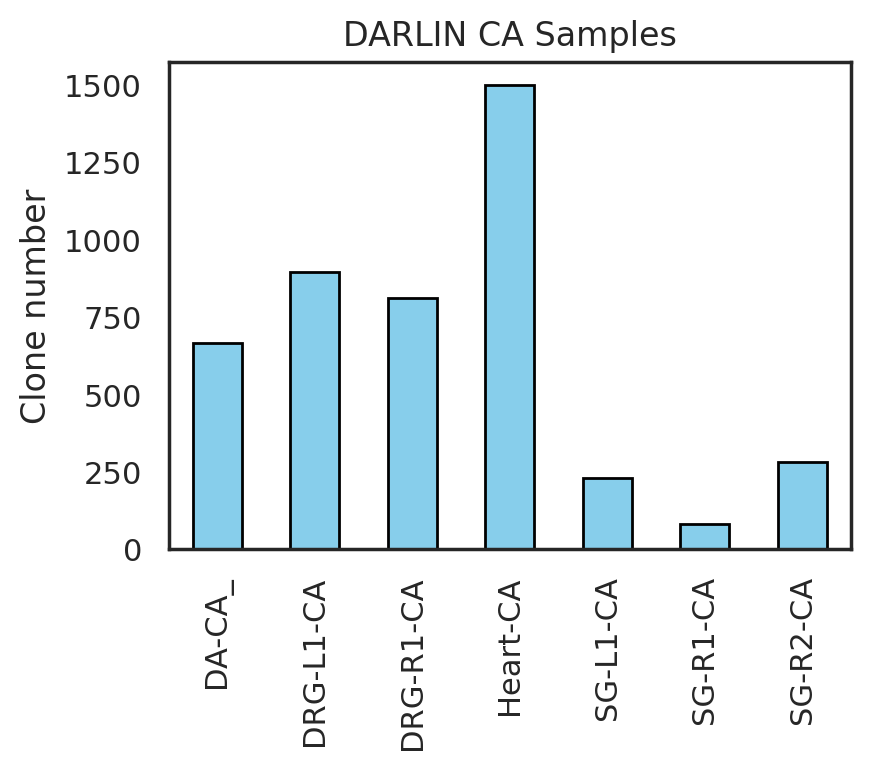

Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/CA/figure/clone_number_CA.pdf


In [ ]:
for mouse in mouse_list:  # mouse_list = ['CA']
    # Load
    df_sc_CARLIN_HQ = pd.read_csv(
        f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv'
    )

    # Create bar plot: clone number per sample
    fig, ax = plt.subplots(figsize=(4.5, 4))
    df_sc_CARLIN_HQ.groupby('sample').agg({'allele': lambda x: len(set(x))}).plot(
        kind='bar', ax=ax, color='skyblue', edgecolor='black'
    )

    plt.xlabel('')
    plt.ylabel('Clone number')
    ax.get_legend().remove()
    plt.title(title_map['Adult'])  
    plt.tight_layout()

    # Save figure
    plt.savefig(f'{paper_figure_path}/clone_number_{mouse}.pdf')
    plt.show()

    print(f"Saved: {paper_figure_path}/clone_number_{mouse}.pdf")


------CA-----


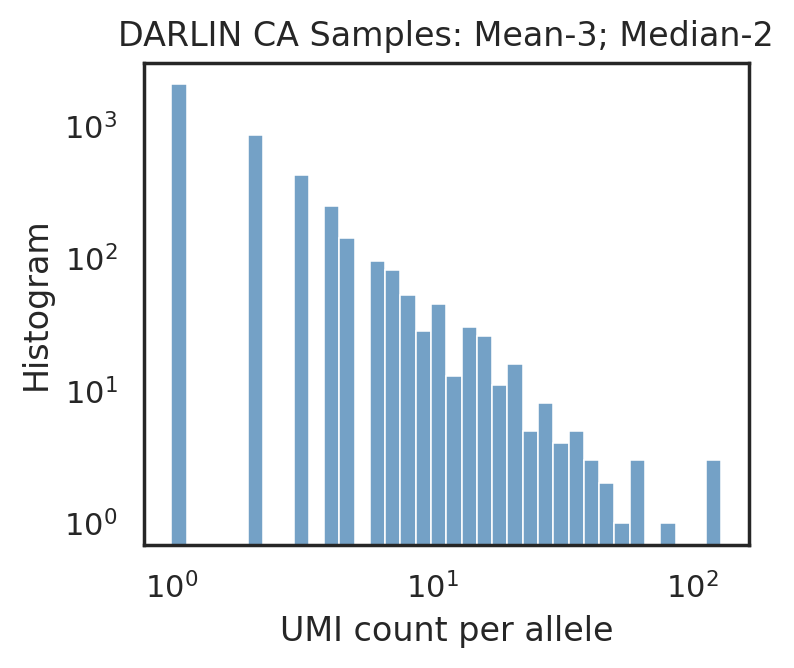

mean: 2.9078630004823927
median: 2.0


In [ ]:
for mouse in mouse_list:  # mouse_list = ['CA']
    print(f'------{mouse}-----')

    # Load the 
    df_sc_CARLIN_HQ = pd.read_csv(
        f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv'
    )

    # === Compute UMI count per allele ===
    fig, ax = plt.subplots(figsize=(4, 3.5))
    df_plot = df_sc_CARLIN_HQ.groupby('allele').agg(
        count=('RNA_id', lambda x: len(set(x)))
    )

    # === Plot histogram ===
    sns.histplot(data=df_plot, x='count', log_scale=True, color='steelblue', edgecolor=None)
    plt.yscale('log')

    # === Compute and display mean/median ===
    X_mean = df_plot['count'].mean()
    X_median = df_plot['count'].median()

    plt.title(f'DARLIN CA Samples: Mean-{X_mean:.0f}; Median-{X_median:.0f}')
    plt.xlabel('UMI count per allele')
    plt.ylabel('Histogram')
    plt.tight_layout()

    # === Save figure ===
    plt.savefig(f'{paper_figure_path}/clone_size_distribution_{mouse}.pdf')
    plt.show()

    print('mean:', X_mean)
    print('median:', X_median)


------ CA ------


100%|██████████| 12056/12056 [00:00<00:00, 819740.77it/s]

Using fates: ['DRG-L1', 'DRG-R1', 'Heart', 'SG-L1', 'SG-R1', 'SG-R2']


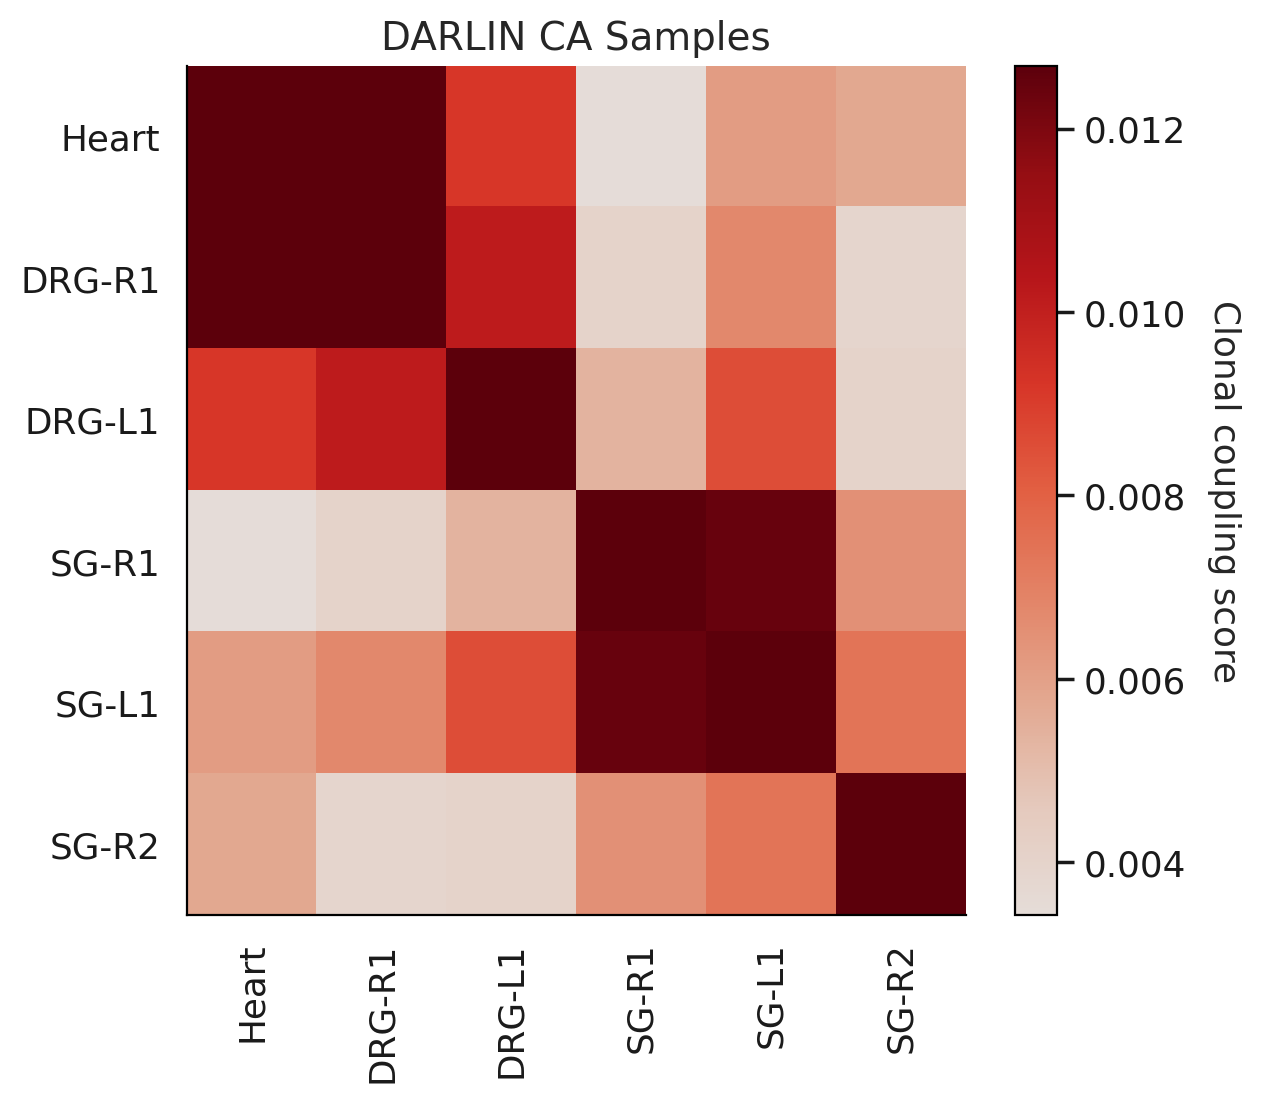

✅ Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/CA/figure/fate_coupling_CA.pdf


In [ ]:
for mouse in mouse_list:  
    print(f"------ {mouse} ------")

    # === Use all CA samples ===
    SampleList_RAW = [x.split('_')[0] for x in SampleList_RAW_0]

 
    short_names = [
        x.replace("DRG-L1-CA", "DRG-L1")
         .replace("DRG-R1-CA", "DRG-R1")
         .replace("SG-L1-CA", "SG-L1")
         .replace("SG-R1-CA", "SG-R1")
         .replace("SG-R2-CA", "SG-R2")
         .replace("DA-CA", "DA")
         .replace("Heart-CA", "Heart")
        for x in SampleList_RAW
    ]

    # === Load high-quality allele data ===
    df_sc_CARLIN_HQ = pd.read_csv(
        f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv'
    )

    # === Generate clone-by-allele matrix ===
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key='allele'
    )

    # === Configure figure settings ===
    cs.settings.set_figure_params(figsize=(6, 5.5))

    # === Rename long sample names → short names ===
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].map(
        dict(zip(SampleList_RAW, short_names))
    )

    # === Convert to string (avoid float issues) ===
    adata_orig.obs['time_info'] = ['CA' in str(x) for x in adata_orig.obs['state_info']]

    # === Filter valid fates present in data ===
    valid_fates = [f for f in short_names if f in adata_orig.obs['state_info'].unique()]
    print("Using fates:", valid_fates)

    # === Compute fate coupling ===
    cs.tl.fate_coupling(
        adata_orig,
        selected_fates=valid_fates,
        source='X_clone',
        normalize=True
    )

    # === Plot fate coupling heatmap ===
    cs.pl.fate_coupling(
        adata_orig,
        source='X_clone',
        title='DARLIN CA Samples'
    )

    # === Save output ===
    plt.savefig(f"{paper_figure_path}/fate_coupling_CA.pdf")
    plt.show()
    print(f"Saved: {paper_figure_path}/fate_coupling_CA.pdf")


------ CA ------


100%|██████████| 12056/12056 [00:00<00:00, 932050.38it/s]

Using fates: ['DRG-L1', 'DA', 'DRG-R1', 'Heart', 'SG-L1', 'SG-R1', 'SG-R2']


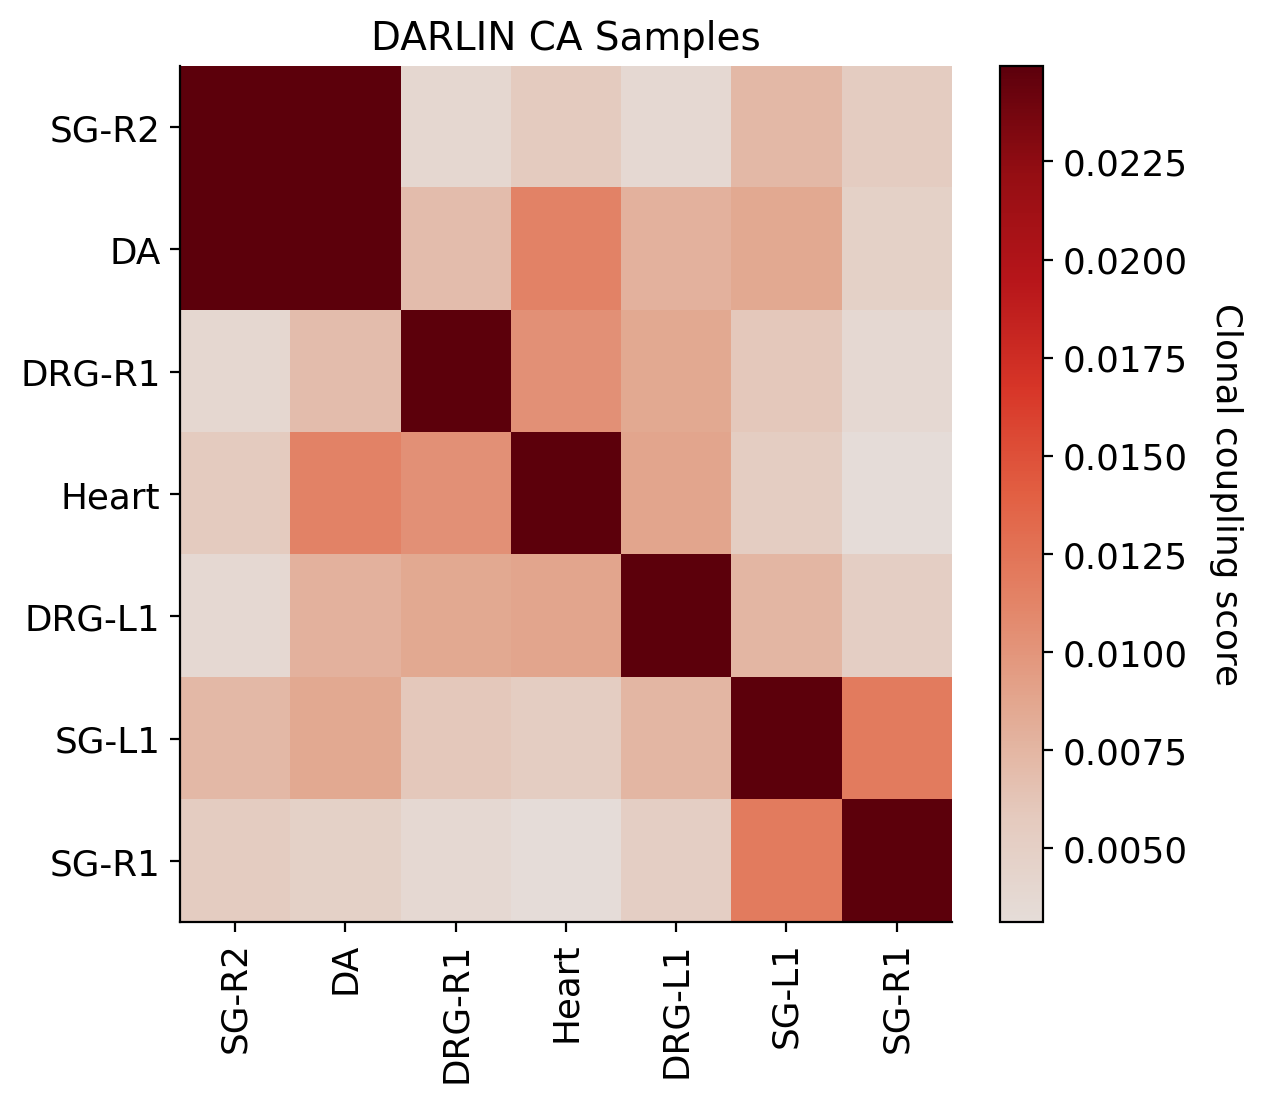

✅ Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/CA/figure/fate_coupling_CA.pdf


In [ ]:
# === Fate Coupling Analysis for CARLIN CA Samples ===

for mouse in mouse_list: 
    print(f"------ {mouse} ------")

    # === Use all CA samples ===
    SampleList_RAW = [x.split('_')[0] for x in SampleList_RAW_0]

    # Define short names (for clarity in heatmap)
    short_names = [
        x.replace("DRG-L1-CA", "DRG-L1")
         .replace("DRG-R1-CA", "DRG-R1")
         .replace("SG-L1-CA", "SG-L1")
         .replace("SG-R1-CA", "SG-R1")
         .replace("SG-R2-CA", "SG-R2")
         .replace("DA-CA", "DA")
         .replace("Heart-CA", "Heart")
        for x in SampleList_RAW
    ]

    # === Load high-quality allele data ===
    df_sc_CARLIN_HQ = pd.read_csv(
        f"{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv"
    )

    # === Generate clone-by-allele matrix ===
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key='allele'
    )

    # === Clean up and rename state_info ===
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('-CA', '', regex=False)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('_$', '', regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('DA$', 'DA', regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].fillna('DA')

    # === Configure figure settings ===
    cs.settings.set_figure_params(figsize=(6, 5.5))

    # Map long → short names
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].map(
        dict(zip(SampleList_RAW, short_names))
    ).fillna(adata_orig.obs['state_info'])

    # Add CA flag
    adata_orig.obs['time_info'] = ['CA' in str(x) for x in adata_orig.obs['state_info']]

    # === Include valid fates only ===
    valid_fates = [f for f in short_names if f in adata_orig.obs['state_info'].unique()]
    print("Using fates:", valid_fates)

    # === Compute fate coupling ===
    cs.tl.fate_coupling(
        adata_orig,
        selected_fates=valid_fates,
        source='X_clone',
        normalize=True
    )

    # === Plot heatmap ===
    cs.pl.fate_coupling(
        adata_orig,
        source='X_clone',
        title='DARLIN CA Samples'
    )

    # === Save output ===
    plt.savefig(f"{paper_figure_path}/fate_coupling_CA.pdf", bbox_inches='tight')
    plt.show()
    print(f"Saved: {paper_figure_path}/fate_coupling_CA.pdf")


------ CA ------


100%|██████████| 12056/12056 [00:00<00:00, 1007201.06it/s]

Reordered fates: ['DA', 'DRG-L1', 'DRG-R1', 'SG-L1', 'SG-R1', 'SG-R2', 'Heart']


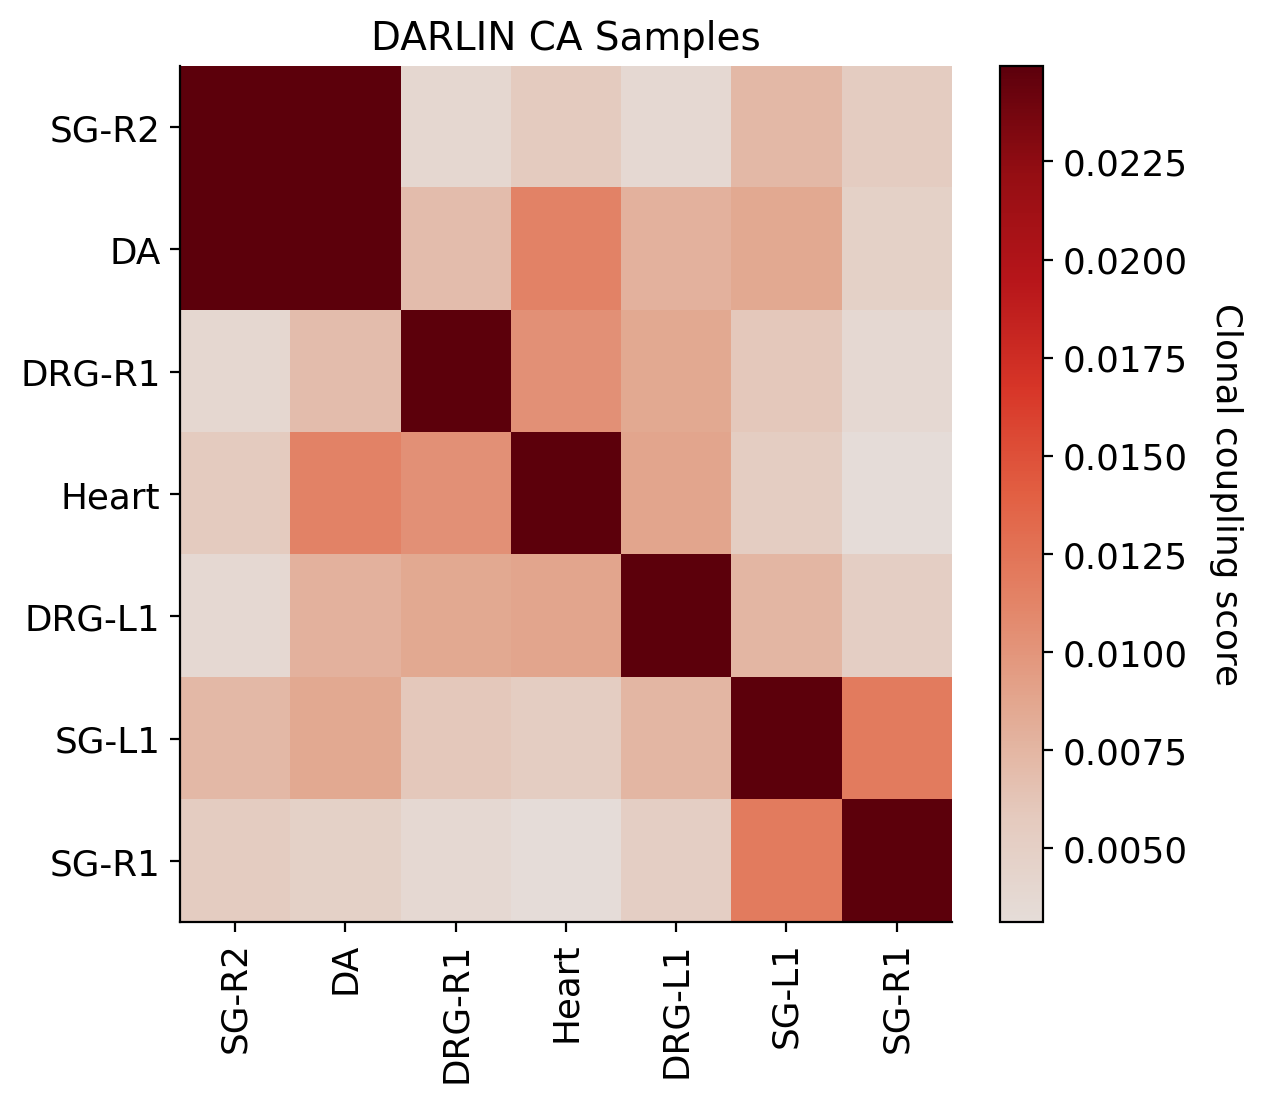

✅ Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/CA/figure/fate_coupling_CA.pdf


In [ ]:
# === Fate Coupling Analysis for CARLIN CA Samples ===

for mouse in mouse_list:  
    print(f"------ {mouse} ------")

    # === Use all CA samples ===
    SampleList_RAW = [x.split('_')[0] for x in SampleList_RAW_0]

    # Define short names (for clarity in heatmap)
    short_names = [
        x.replace("DRG-L1-CA", "DRG-L1")
         .replace("DRG-R1-CA", "DRG-R1")
         .replace("SG-L1-CA", "SG-L1")
         .replace("SG-R1-CA", "SG-R1")
         .replace("SG-R2-CA", "SG-R2")
         .replace("DA-CA", "DA")
         .replace("Heart-CA", "Heart")
        for x in SampleList_RAW
    ]

    # === Load high-quality allele data ===
    df_sc_CARLIN_HQ = pd.read_csv(
        f"{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv"
    )

    # === Generate clone-by-allele matrix ===
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key='allele'
    )

    # === Clean up and rename state_info ===
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('-CA', '', regex=False)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('_$', '', regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('DA$', 'DA', regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].fillna('DA')

    # === Configure figure settings ===
    cs.settings.set_figure_params(figsize=(6, 5.5))

    # Map long → short names
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].map(
        dict(zip(SampleList_RAW, short_names))
    ).fillna(adata_orig.obs['state_info'])

    # Add CA flag
    adata_orig.obs['time_info'] = ['CA' in str(x) for x in adata_orig.obs['state_info']]

    # === Include valid fates only ===
    valid_fates = [f for f in short_names if f in adata_orig.obs['state_info'].unique()]

    # === Reorder for better visualization ===
    desired_order = ['DA', 'DRG-L1', 'DRG-R1', 'SG-L1', 'SG-R1', 'SG-R2', 'Heart']
    valid_fates = [f for f in desired_order if f in valid_fates]

    print("Reordered fates:", valid_fates)

    # === Compute fate coupling ===
    cs.tl.fate_coupling(
        adata_orig,
        selected_fates=valid_fates,
        source='X_clone',
        normalize=True
    )

    # === Plot heatmap ===
    cs.pl.fate_coupling(
        adata_orig,
        source='X_clone',
        title='DARLIN CA Samples'
    )

    # === Save output ===
    output_path = f"{paper_figure_path}/fate_coupling_CA.pdf"
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()

    print(f"Saved: {output_path}")


------ CA ------


100%|██████████| 12056/12056 [00:00<00:00, 904281.71it/s]

Using fates: ['DRG-L1', 'DRG-R1', 'Heart-CA', 'SG-L1', 'SG-R1', 'SG-R2']


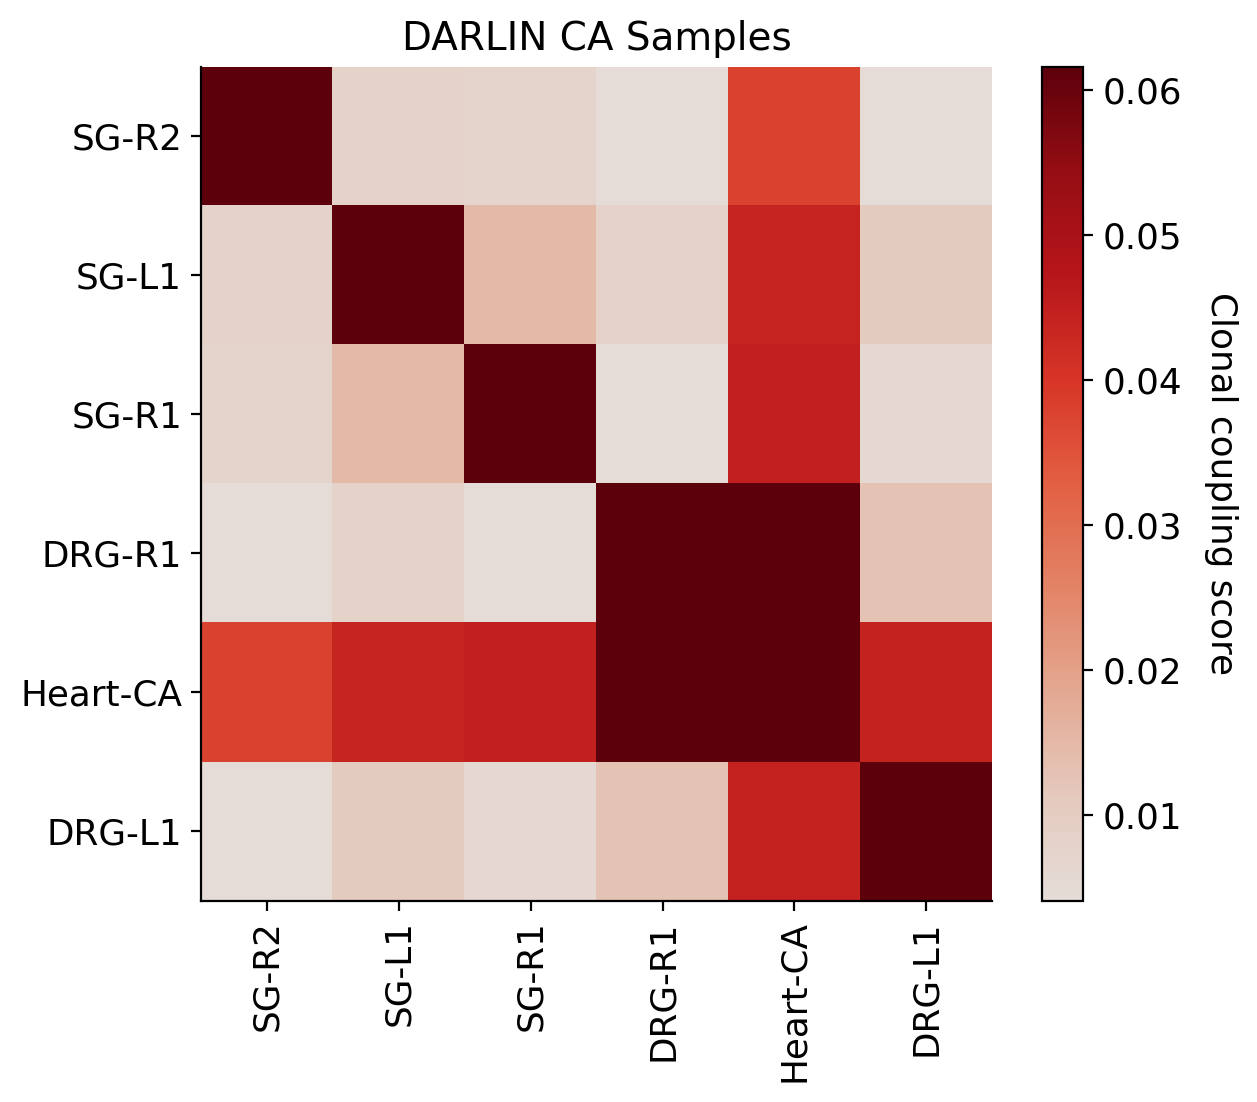

Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/CA/figure/fate_coupling_CA.pdf


In [16]:
for mouse in mouse_list:  # mouse_list = ['CA']
    print(f"------ {mouse} ------")

    # === Use all CA samples ===
    SampleList_RAW = [x.split('_')[0] for x in SampleList_RAW_0]

    # Short names
    short_names = [
        x.replace("DRG-L1-CA", "DRG-L1")
         .replace("DRG-R1-CA", "DRG-R1")
         .replace("SG-L1-CA", "SG-L1")
         .replace("SG-R1-CA", "SG-R1")
         .replace("SG-R2-CA", "SG-R2")
         .replace("DA-CA", "DA")
         .replace("Heart-CA", "Heart")
        for x in SampleList_RAW
    ]

    # Load high-quality allele data
    df_sc_CARLIN_HQ = pd.read_csv(
        f'{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv'
    )

    # Generate clone-by-allele matrix
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key='allele'
    )

    cs.settings.set_figure_params(figsize=(6, 5.5))

    # Rename long sample names → short names
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].map(
        dict(zip(SampleList_RAW, short_names))
    )

    # Convert to string to avoid float error
    adata_orig.obs['time_info'] = ['CA' in str(x) for x in adata_orig.obs['state_info']]

    # Only include valid fates present in data
    valid_fates = [f for f in short_names if f in adata_orig.obs['state_info'].unique()]
    print("Using fates:", valid_fates)

    # Compute fate coupling
    cs.tl.fate_coupling(
        adata_orig,
        selected_fates=valid_fates,
        source='X_clone',
        normalize=True
    )

    # Plot heatmap
    cs.pl.fate_coupling(
        adata_orig,
        source='X_clone',
        title='DARLIN CA Samples'
    )

    plt.savefig(f"{paper_figure_path}/fate_coupling_CA.pdf")
    plt.show()
    print(f"Saved: {paper_figure_path}/fate_coupling_CA.pdf")


------ CA ------


100%|██████████| 12056/12056 [00:00<00:00, 1040142.53it/s]

Reordered fates: ['DA', 'DRG-L1', 'DRG-R1', 'SG-L1', 'SG-R1', 'SG-R2']


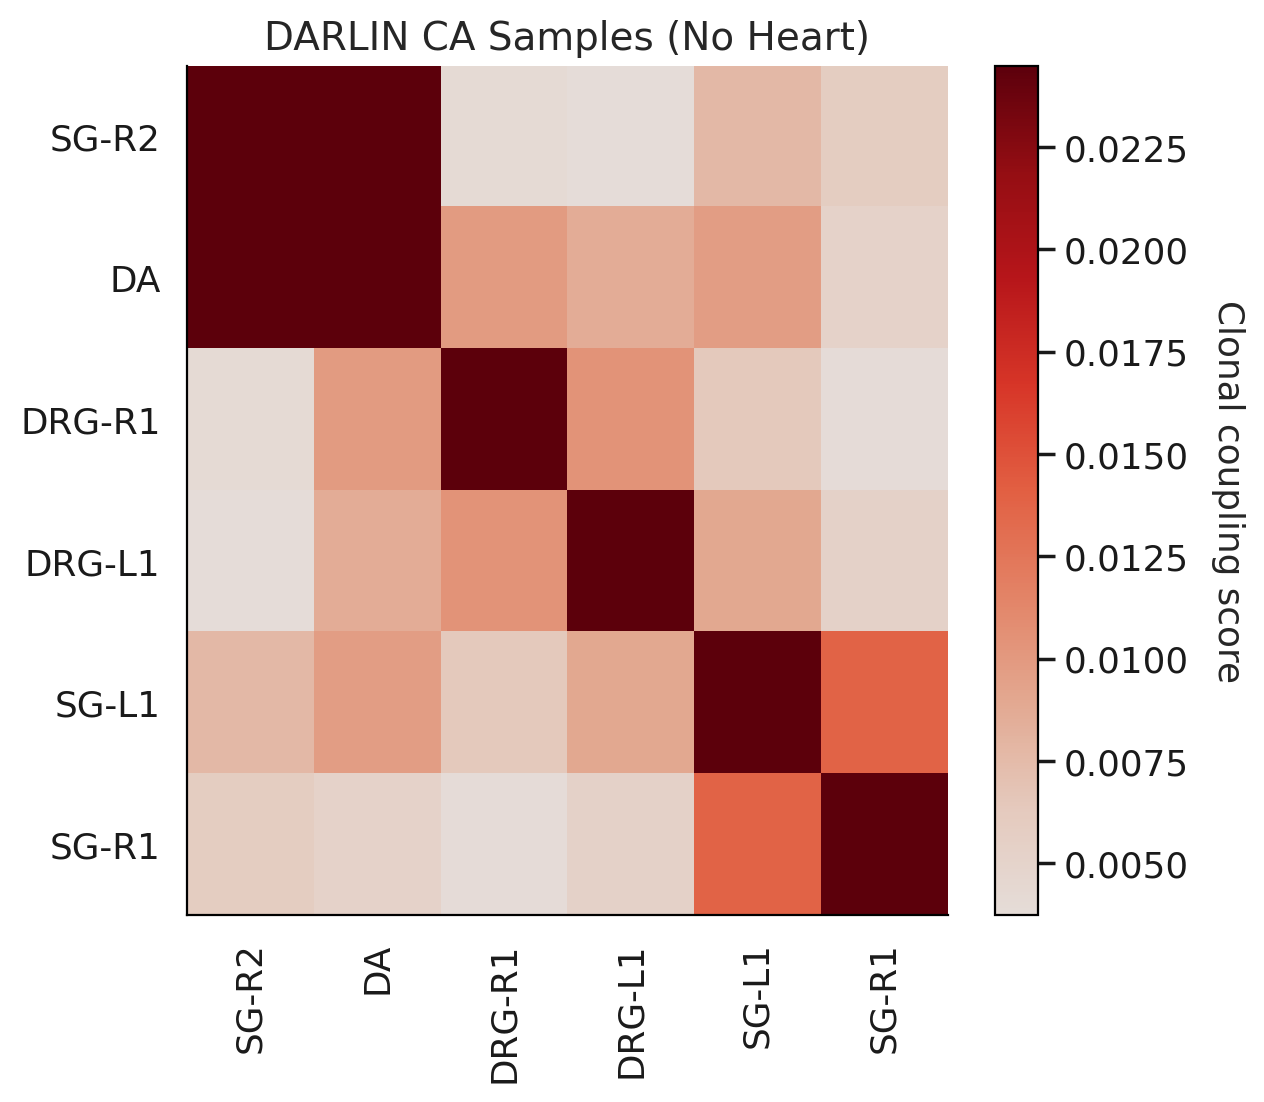

✅ Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/CA/figure/fate_coupling_CA_noHeart.pdf


In [ ]:
# === Fate Coupling Analysis for CARLIN CA Samples (No Heart) ===

for mouse in mouse_list:  
    print(f"------ {mouse} ------")

    # === Use all CA samples ===
    SampleList_RAW = [x.split('_')[0] for x in SampleList_RAW_0]

    # Define short names
    short_names = [
        x.replace("DRG-L1-CA", "DRG-L1")
         .replace("DRG-R1-CA", "DRG-R1")
         .replace("SG-L1-CA", "SG-L1")
         .replace("SG-R1-CA", "SG-R1")
         .replace("SG-R2-CA", "SG-R2")
         .replace("DA-CA", "DA")
         .replace("Heart-CA", "Heart")
        for x in SampleList_RAW
    ]

    # === Load high-quality allele data ===
    df_sc_CARLIN_HQ = pd.read_csv(
        f"{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv"
    )

    # === Generate clone-by-allele matrix ===
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key='allele'
    )

    # === Clean up and rename ===
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('-CA', '', regex=False)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('_$', '', regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('DA$', 'DA', regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].fillna('DA')

    cs.settings.set_figure_params(figsize=(6, 5.5))

    # Map long → short names
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].map(
        dict(zip(SampleList_RAW, short_names))
    ).fillna(adata_orig.obs['state_info'])

    # Remove "Heart"
    adata_orig = adata_orig[adata_orig.obs['state_info'] != 'Heart', :].copy()

    # Add CA flag
    adata_orig.obs['time_info'] = ['CA' in str(x) for x in adata_orig.obs['state_info']]

    # Include valid fates
    valid_fates = [f for f in short_names if f in adata_orig.obs['state_info'].unique()]

    # Reorder for visualization (Heart removed)
    desired_order = ['DA', 'DRG-L1', 'DRG-R1', 'SG-L1', 'SG-R1', 'SG-R2']
    valid_fates = [f for f in desired_order if f in valid_fates]

    print("Reordered fates:", valid_fates)

    # Compute fate coupling
    cs.tl.fate_coupling(
        adata_orig,
        selected_fates=valid_fates,
        source='X_clone',
        normalize=True
    )

    # Plot heatmap
    cs.pl.fate_coupling(
        adata_orig,
        source='X_clone',
        title='DARLIN CA Samples (No Heart)'
    )

    # Save output
    output_path = f"{paper_figure_path}/fate_coupling_CA_noHeart.pdf"
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()

    print(f"Saved: {output_path}")


------ CA ------


100%|██████████| 12056/12056 [00:00<00:00, 872739.54it/s]


Reordered fates: ['DRG-L1', 'SG-L1', 'DRG-R1', 'SG-R1', 'SG-R2']


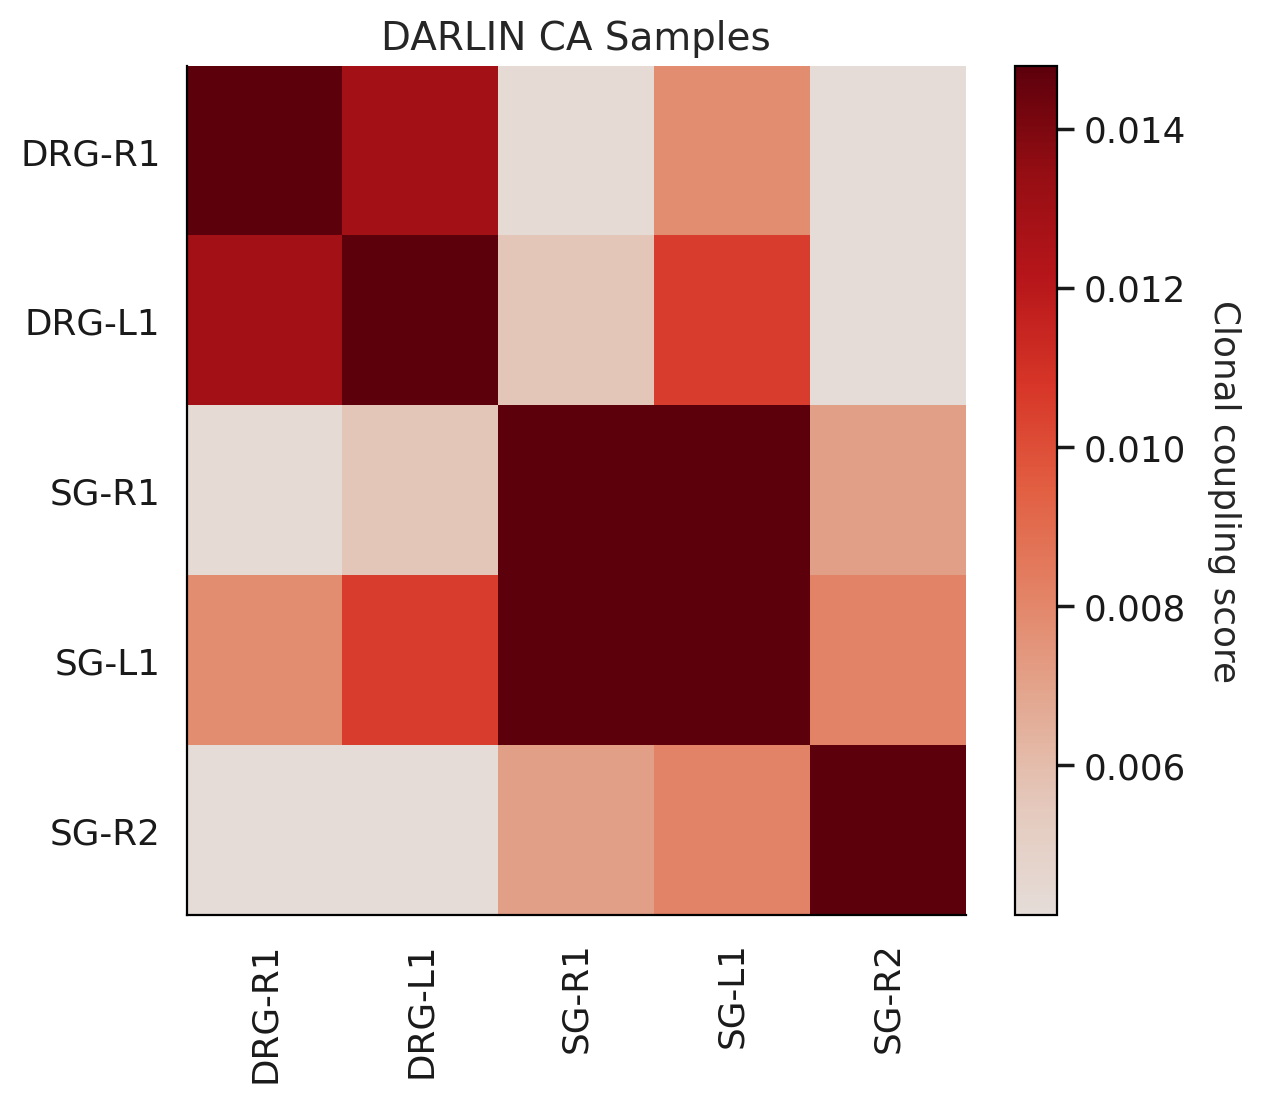

✅ Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/figure/fate_coupling_CA_noHeart_reordered.pdf


In [ ]:
# === Fate Coupling Analysis for CARLIN CA Samples (No Heart, Balanced) ===

for mouse in mouse_list:  # e.g. mouse_list = ['CA']
    print(f"------ {mouse} ------")

    # === Use all CA samples ===
    SampleList_RAW = [x.split('_')[0] for x in SampleList_RAW_0]

    # Define short names
    short_names = [
        x.replace("DRG-L1-CA", "DRG-L1")
         .replace("DRG-R1-CA", "DRG-R1")
         .replace("SG-L1-CA", "SG-L1")
         .replace("SG-R1-CA", "SG-R1")
         .replace("SG-R2-CA", "SG-R2")
         .replace("DA-CA", "DA")
         .replace("Heart-CA", "Heart")
        for x in SampleList_RAW
    ]

    # === Load high-quality allele data ===
    df_sc_CARLIN_HQ = pd.read_csv(
        f"{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv"
    )

    # === Generate clone-by-allele matrix ===
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key='allele'
    )

    # === Clean and rename ===
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('-CA', '', regex=False)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('_$', '', regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].str.replace('DA$', 'DA', regex=True)
    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].fillna('DA')

    cs.settings.set_figure_params(figsize=(6, 5.5))

    adata_orig.obs['state_info'] = adata_orig.obs['state_info'].map(
        dict(zip(SampleList_RAW, short_names))
    ).fillna(adata_orig.obs['state_info'])

    # Remove Heart
    adata_orig = adata_orig[adata_orig.obs['state_info'] != 'Heart', :].copy()

    # Add CA flag
    adata_orig.obs['time_info'] = ['CA' in str(x) for x in adata_orig.obs['state_info']]

    # Include valid fates
    valid_fates = [f for f in short_names if f in adata_orig.obs['state_info'].unique()]

    # === Simple reordered layout (balanced visually) ===
    desired_order = ['DRG-L1', 'SG-L1', 'DRG-R1', 'SG-R1', 'SG-R2']
    valid_fates = [f for f in desired_order if f in valid_fates]

    print("Reordered fates:", valid_fates)

    # Compute fate coupling
    cs.tl.fate_coupling(
        adata_orig,
        selected_fates=valid_fates,
        source='X_clone',
        normalize=True
    )

    # Plot heatmap
    cs.pl.fate_coupling(
        adata_orig,
        source='X_clone',
        title='DARLIN CA Samples'
    )

    # Save output
    output_path = f"{paper_figure_path}/fate_coupling_CA_noHeart_reordered.pdf"
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()

    print(f" Saved: {output_path}")


100%|██████████| 12056/12056 [00:00<00:00, 992824.33it/s]


Fixed order: ['DRG-L1', 'SG-L1', 'DRG-R1', 'SG-R1', 'SG-R2']


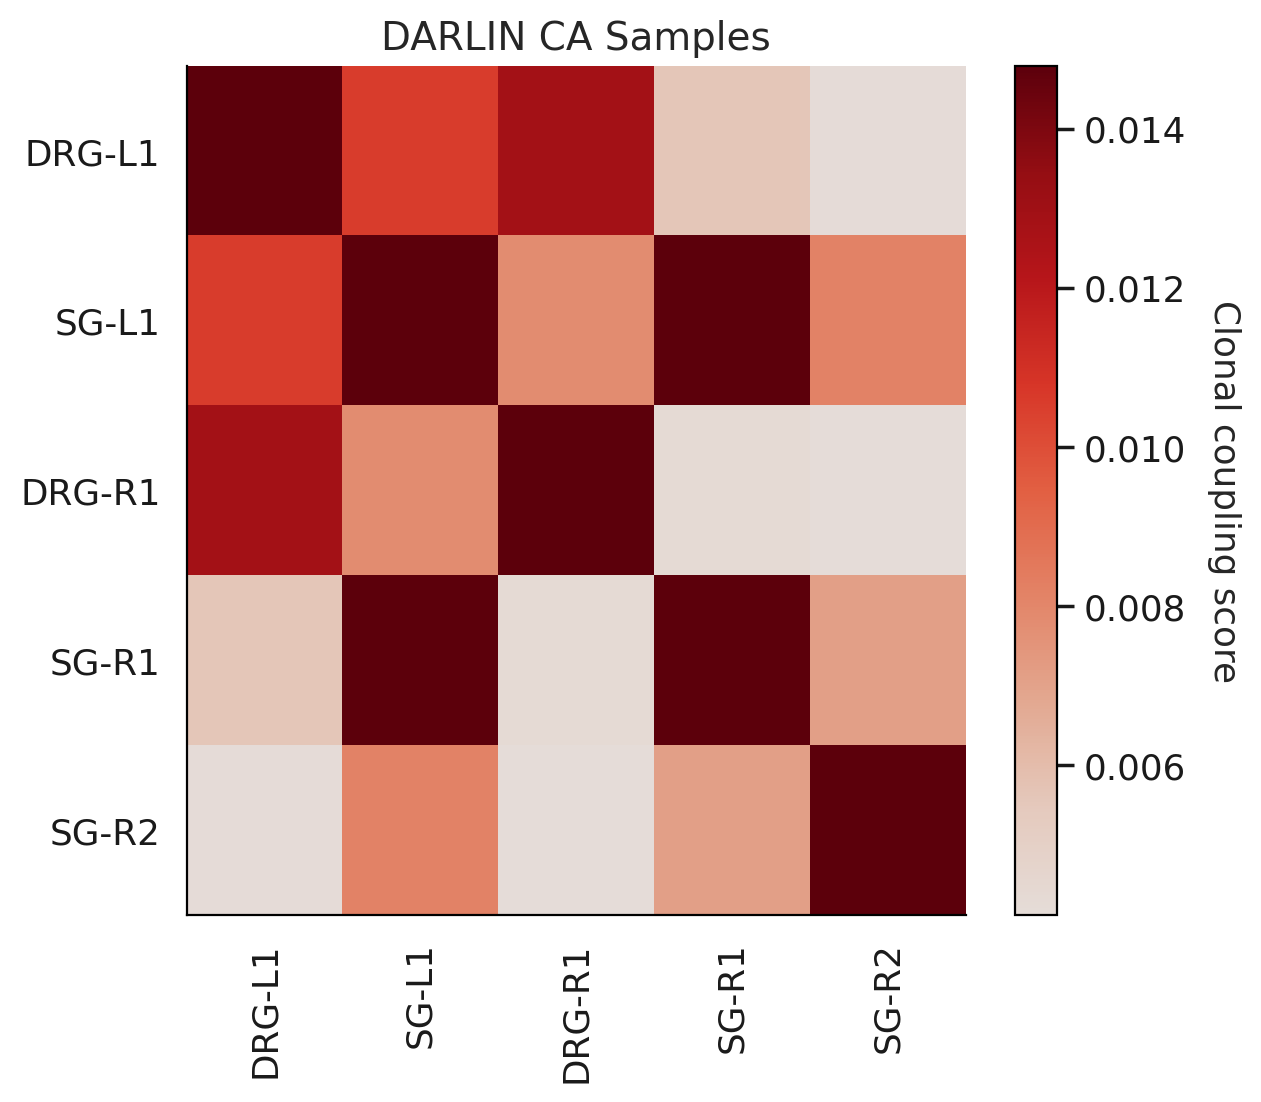

In [26]:
# === Fate Coupling Analysis for CARLIN CA Samples (No Heart, fixed order) ===
for mouse in mouse_list:  # ['CA']
    SampleList_RAW = [x.split('_')[0] for x in SampleList_RAW_0]

    short_names = [
        x.replace("DRG-L1-CA","DRG-L1").replace("DRG-R1-CA","DRG-R1")
         .replace("SG-L1-CA","SG-L1").replace("SG-R1-CA","SG-R1")
         .replace("SG-R2-CA","SG-R2").replace("DA-CA","DA")
         .replace("Heart-CA","Heart") for x in SampleList_RAW
    ]

    df_sc_CARLIN_HQ = pd.read_csv(
        f"{root_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv"
    )
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ, min_clone_size=min_clone_size, clone_id_key='allele'
    )

    # clean + map names
    si = adata_orig.obs['state_info'].str.replace('-CA','',regex=False)
    si = si.str.replace('_$','',regex=True).str.replace('DA$','DA',regex=True)
    adata_orig.obs['state_info'] = si.map(dict(zip(SampleList_RAW, short_names))).fillna(si)

    # drop Heart
    adata_orig = adata_orig[adata_orig.obs['state_info'] != 'Heart', :].copy()

    # fixed display order (balanced)
    desired_order = ['DRG-L1','SG-L1','DRG-R1','SG-R1','SG-R2']
    valid_fates   = [f for f in desired_order if f in adata_orig.obs['state_info'].unique()]
    print("Fixed order:", valid_fates)

    # compute + plot (disable map ordering)
    cs.tl.fate_coupling(adata_orig, selected_fates=valid_fates, source='X_clone', normalize=True)
    cs.pl.fate_coupling(
        adata_orig,
        source='X_clone',
        title='DARLIN CA Samples',
        order_map_x=False,   # <- keep your order on x
        order_map_y=False    # <- keep your order on y
    )

    plt.savefig(f"{paper_figure_path}/fate_coupling_CA_noHeart_reordered.pdf", bbox_inches='tight')
    plt.show()


------ CA ------
Reading: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/merge_all/df_allele_all_CA__freqCutoff0.1_HQ_BCcomplex4_freq0.1.csv


100%|██████████| 12056/12056 [00:00<00:00, 869318.68it/s]


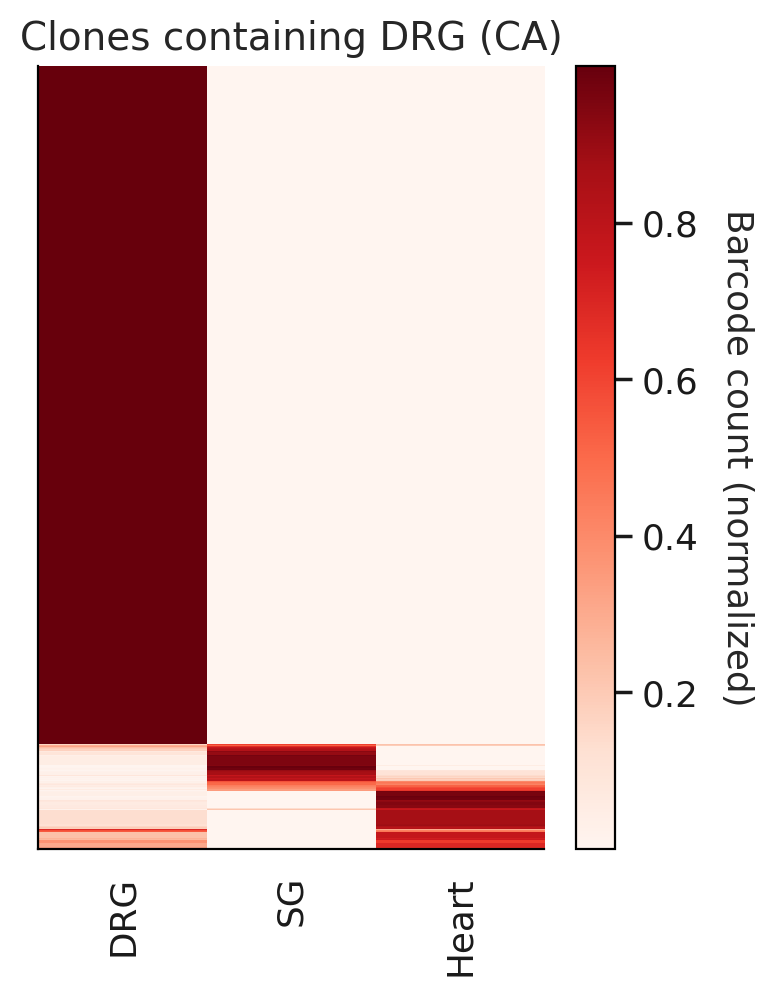

Saved: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/figure/restricted_barcode_heatmap_tissue_CA.pdf


In [67]:
# === Restricted Barcode Heatmap for CA Dataset ===

import os
import pandas as pd
import matplotlib.pyplot as plt
import cospar as cs
import mosaiclineage.help_functions as hf
import mosaiclineage.plot_scripts as mosaic_pl

# === Basic parameters ===
mouse_list = ['CA']
BC_complexity = 4
frequency_cutoff = 0.1
min_clone_size = 2

# === Paths ===
data_path = '/scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3'
paper_figure_path = os.path.join(data_path, 'figure')
os.makedirs(paper_figure_path, exist_ok=True)

# === Loop through mouse_list (only CA in your case) ===
for mouse in mouse_list:
    print(f"------ {mouse} ------")

    # Define sample groups for your CA dataset
    SampleList_RAW_1 = [
        "DRG-L1-CA", "DRG-R1-CA",
        "SG-L1-CA", "SG-R1-CA", "SG-R2-CA",
        "DA-CA_", "Heart-CA"
    ]

    # Group samples by tissue (same structure as tutorial)
    SampleList_RAW_2 = [
        ["DRG-L1-CA", "DRG-R1-CA"],            # DRG
        ["SG-L1-CA", "SG-R1-CA", "SG-R2-CA"],  # SG
        ["DA-CA_", "Heart-CA"]                 # DA + Heart
    ]

    # Short labels for plotting
    short_names = ["DRG", "SG", "Heart"]

    # === Load high-quality allele file ===
    file_path = f'{data_path}/merge_all/df_allele_all_{mouse}__freqCutoff{frequency_cutoff}_HQ_BCcomplex{BC_complexity}_freq{frequency_cutoff}.csv'
    print("Reading:", file_path)
    df_sc_CARLIN_HQ = pd.read_csv(file_path)

    # === Generate adata object ===
    adata_orig = hf.generate_adata_cell_by_allele(
        df_sc_CARLIN_HQ,
        min_clone_size=min_clone_size,
        clone_id_key='allele'
    )

    # === Plot Restricted Barcode Heatmap ===
    cs.settings.set_figure_params(figsize=(4, 4))

    mosaic_pl.analyze_cell_coupling_core(
        adata_orig,
        selected_fates=SampleList_RAW_2,
        short_names=short_names,
        remove_single_lineage_clone=False,
        plot_sample_number=False,
        plot_barcodes_binary=False,
        plot_barcodes_normalize=False,
        plot_restricted=True,
        plot_cell_count=False,
        plot_hierarchy=False,
        plot_Jaccard=False,
        plot_pie=False,
        plot_correlation=False,
        order_map=False,
        included_fates_N=[0],
        included_fates_mode="only",
        time_info=None,
        print_matrix=False,
        figure_path=paper_figure_path,
        data_des=f"{mouse}",
        vmax=0.25,
    )

    plt.title(f"Clones containing {short_names[0]} ({mouse})")
    plt.tight_layout()
    plt.savefig(f"{paper_figure_path}/restricted_barcode_heatmap_tissue_{mouse}.pdf")
    plt.show()

    print(f"Saved: {paper_figure_path}/restricted_barcode_heatmap_tissue_{mouse}.pdf")


In [68]:
# ============================================================
#   Compute tissue overlap fractions for CA dataset
#   (fixed version — matches DARLIN tutorial logic)
# ============================================================

data_des = 'distinguish_ref_type'

for mouse in ['CA']:  # your dataset
    df_all_list = []
    for BC_complexity_tmp in [2, 4, 6]:
        print(f"\n========== Processing {mouse}, BC_complexity={BC_complexity_tmp} ==========")

        # === Read HQ allele data ===
        df_sc_CARLIN_HQ = pd.read_csv(
            f"{data_path}/merge_all/df_allele_all_{mouse}_{save_data_des}_HQ_BCcomplex{BC_complexity_tmp}_freq{frequency_cutoff}.csv"
        )

        # --- Group by allele & sample ---
        df_clone = (
            df_sc_CARLIN_HQ.groupby(['allele', 'sample'])
            .agg(count=('RNA_id', lambda x: len(set(x))))
            .reset_index()
        )

        # --- Tissue extraction ---
        # Examples:
        #  DRG-L1-CA_S1_L001 → DRG-L1
        #  DA-CA_S11_L001 → DA-CA
        #  Heart-CA_S9_L001 → Heart-CA
        def extract_tissue(sample_name):
            parts = sample_name.split('-')
            if len(parts) >= 2:
                return '-'.join(parts[:2])
            else:
                return parts[0]

        df_clone['tissue'] = df_clone['sample'].apply(extract_tissue)

        # --- Filter high-quality clones ---
        df_tmp = df_clone.groupby('allele').agg({'count': 'sum'})
        df_clone_HQ = df_clone[
            df_clone['allele'].isin(df_tmp[df_tmp['count'] >= min_clone_size].index)
        ]

        HQ_clone_N = len(df_sc_CARLIN_HQ['allele'].unique())
        twoCell_Clone_N = len(df_clone_HQ['allele'].unique())
        print(f"HQ clone Num: {HQ_clone_N}; HQ clone with >1 cells: {twoCell_Clone_N}")

        # --- Group before pivot to avoid duplicates ---
        df_clone_HQ_grouped = (
            df_clone_HQ.groupby(['tissue', 'allele'], as_index=False)['count'].sum()
        )

        # --- Build tissue × allele count table ---
        df_table = (
            df_clone_HQ_grouped
            .pivot(index='tissue', columns='allele', values='count')
            .fillna(0)
            .T
        )

        print(f" df_table shape: {df_table.shape}")
        print(f" Tissues in table: {list(df_table.columns)}")

        # --- Binary overlap matrix (presence/absence) ---
        df_tmp_count = (df_table.T.to_numpy() > 0).astype(int)
        share_N_matrix = np.dot(df_tmp_count, df_tmp_count.T)
        tissue_list = list(df_table.columns)

        # FIX: No celltype info → treat all as same type (CA)
        celltype_list = ['CA']

        # --- Compute overlap for each tissue ---
        for tissue in tissue_list:
            tissue_list_tmp = [t for t in tissue_list if t != tissue]
            df_list = []

            # Only one celltype ('CA') here
            target_id = tissue
            reference_id_list = [tissue_list_tmp]

            print(f"----- target_id: {target_id}")
            print(f"----- reference ids: {reference_id_list}")

            # --- Sanity check ---
            if target_id not in df_table.columns:
                print(f" Skipping {target_id}: not found in df_table columns.")
                continue

            # --- Compute overlap fraction ---
            df = mosaic_pl.bar_plot_for_inverse_overlap(
                df_table,
                target_id=target_id,
                reference_id_list=reference_id_list,
                tissue_color_map=None,
                plot=False,
            )

            df['target_id'] = target_id
            df_list.append(df)

            if df_list:
                df_all = pd.concat(df_list, ignore_index=True)
                df_all['tissue'] = tissue
                df_all['mouse'] = mouse
                df_all['allele_complexity'] = BC_complexity_tmp
                df_all['read_cutoff'] = read_cutoff
                df_all['min_clone_size'] = min_clone_size
                df_all_list.append(df_all)

    # === Combine results for this mouse ===
    if df_all_list:
        df_final = pd.concat(df_all_list)
        df_final['overlap_fraction'] = 100 * df_final['overlap_fraction']
        df_final['target_cell_type'] = 'CA'
        df_final['ref_N'] = df_final['ref_cell_type'].apply(lambda x: len(x.split('_')))

        # Optional mapping (if defined)
        if 'mouse_map' in globals() and 'stage_id_map' in globals():
            df_final['stage'] = df_final['mouse'].map(mouse_map)
            df_final['stage_id'] = df_final['stage'].map(stage_id_map)

        # Save to CSV
        out_path = f"{data_analysis_path}/overlapping_across_tissue_{mouse}_{data_des}_all_info_{save_data_des}.csv"
        df_final.to_csv(out_path, index=False)
        print(f"\n Saved overlap results for {mouse} → {out_path}")
    else:
        print(f" No valid overlap data for {mouse}.")



========== Processing CA, BC_complexity=2 ==========
HQ clone Num: 7382; HQ clone with >1 cells: 4081
 df_table shape: (4081, 7)
 Tissues in table: ['DA-CA_', 'DRG-L1', 'DRG-R1', 'Heart-CA', 'SG-L1', 'SG-R1', 'SG-R2']
----- target_id: DA-CA_
----- reference ids: [['DRG-L1', 'DRG-R1', 'Heart-CA', 'SG-L1', 'SG-R1', 'SG-R2']]
----- target_id: DRG-L1
----- reference ids: [['DA-CA_', 'DRG-R1', 'Heart-CA', 'SG-L1', 'SG-R1', 'SG-R2']]
----- target_id: DRG-R1
----- reference ids: [['DA-CA_', 'DRG-L1', 'Heart-CA', 'SG-L1', 'SG-R1', 'SG-R2']]
----- target_id: Heart-CA
----- reference ids: [['DA-CA_', 'DRG-L1', 'DRG-R1', 'SG-L1', 'SG-R1', 'SG-R2']]
----- target_id: SG-L1
----- reference ids: [['DA-CA_', 'DRG-L1', 'DRG-R1', 'Heart-CA', 'SG-R1', 'SG-R2']]
----- target_id: SG-R1
----- reference ids: [['DA-CA_', 'DRG-L1', 'DRG-R1', 'Heart-CA', 'SG-L1', 'SG-R2']]
----- target_id: SG-R2
----- reference ids: [['DA-CA_', 'DRG-L1', 'DRG-R1', 'Heart-CA', 'SG-L1', 'SG-R1']]

========== Processing CA, BC_co

In [ ]:


import os
import pandas as pd

data_des = 'distinguish_ref_type'
df_list = []

print("\n=== 🔍 Starting merge of overlap analysis results ===")

# Ensure mouse_list exists — if not, fallback to single CA
if 'mouse_list' not in globals():
    mouse_list = ['CA']

for mouse in mouse_list:
    file_path = f"{data_analysis_path}/overlapping_across_tissue_{mouse}_{data_des}_all_info_{save_data_des}.csv"
    
    if os.path.exists(file_path):
        print(f" Reading overlap results for {mouse}: {file_path}")
        df_tmp = pd.read_csv(file_path)

        # --- Standardize expected columns ---
        df_tmp['mouse'] = df_tmp.get('mouse', mouse)
        df_tmp['stage'] = df_tmp.get('stage', mouse_map.get(mouse, 'Unknown') if 'mouse_map' in globals() else 'Unknown')

        # Fill in defaults if missing
        for col in ['read_cutoff', 'min_clone_size', 'allele_complexity', 'overlap_fraction']:
            if col not in df_tmp.columns:
                df_tmp[col] = None

        print(f" Loaded {len(df_tmp)} rows with columns: {list(df_tmp.columns)}")
        df_list.append(df_tmp)
    else:
        print(f" Skipping {mouse}: file not found → {file_path}")

# === Combine all DataFrames ===
if df_list:
    df_final = pd.concat(df_list, ignore_index=True)
    n_rows, n_cols = df_final.shape
    print(f"\n Successfully combined {len(df_list)} mice datasets.")
    print(f"Final merged shape: {n_rows} rows × {n_cols} columns")

    # --- Save merged output ---
    merged_path = f"{data_analysis_path}/merged_overlapping_across_tissue_all_{data_des}_{save_data_des}.csv"
    df_final.to_csv(merged_path, index=False)
    print(f" Saved merged results → {merged_path}")

    # --- Summary section ---
    print("\n Summary by stage and mouse:")
    summary = (
        df_final.groupby(['stage', 'mouse'])
        .size()
        .reset_index(name='N_rows')
        .sort_values(['stage', 'mouse'])
    )
    display(summary)

    print("\n Quick stats:")
    print(f"• Unique stages: {df_final['stage'].unique().tolist()}")
    print(f"• Unique mice: {df_final['mouse'].unique().tolist()}")
    print(f"• Unique tissues: {df_final['tissue'].unique().tolist() if 'tissue' in df_final.columns else 'N/A'}")
else:
    print("\n No overlap result files found. Please check:")
    print(f"  → data_analysis_path: {data_analysis_path}")
    print(f"  → mouse_list: {mouse_list}")
    print(f"  → data_des: {data_des}")



=== 🔍 Starting merge of overlap analysis results ===
 Reading overlap results for CA: /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/CA/data/overlapping_across_tissue_CA_distinguish_ref_type_all_info__freqCutoff0.1.csv
 Loaded 21 rows with columns: ['ref_cell_type', 'overlap_clone_N', 'ref_clone_N', 'overlap_fraction', 'target_clone_N', 'target_id', 'tissue', 'mouse', 'allele_complexity', 'read_cutoff', 'min_clone_size', 'target_cell_type', 'ref_N', 'stage', 'stage_id']

 Successfully combined 1 mice datasets.
Final merged shape: 21 rows × 15 columns
 Saved merged results → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/CA/data/merged_overlapping_across_tissue_all_distinguish_ref_type__freqCutoff0.1.csv

 Summary by stage and mouse:


,stage,mouse,N_rows
0,Adult,CA,21



 Quick stats:
• Unique stages: ['Adult']
• Unique mice: ['CA']
• Unique tissues: ['DA-CA_', 'DRG-L1', 'DRG-R1', 'Heart-CA', 'SG-L1', 'SG-R1', 'SG-R2']



=== Stage: Adult ===
  → Rows after filtering: 7
  → Unique tissues: ['DA-CA_' 'DRG-L1' 'DRG-R1' 'Heart-CA' 'SG-L1' 'SG-R1' 'SG-R2']
  → target_cell_type values: ['CA']
ℹ️ Generated numeric IDs for 1 cell type(s): ['CA']
🎨 Adding missing tissue colors for: ['DA-CA_', 'Heart-CA']
✅ Saved plot for Adult → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/figure/max_overlap_with_other_tissues_over_celltype_distinguish_ref_type_Adult.pdf


,celltype_id,overlap_fraction
0,0,27.15871



✅ Combined p-value summary:


,name,pvalue,variable


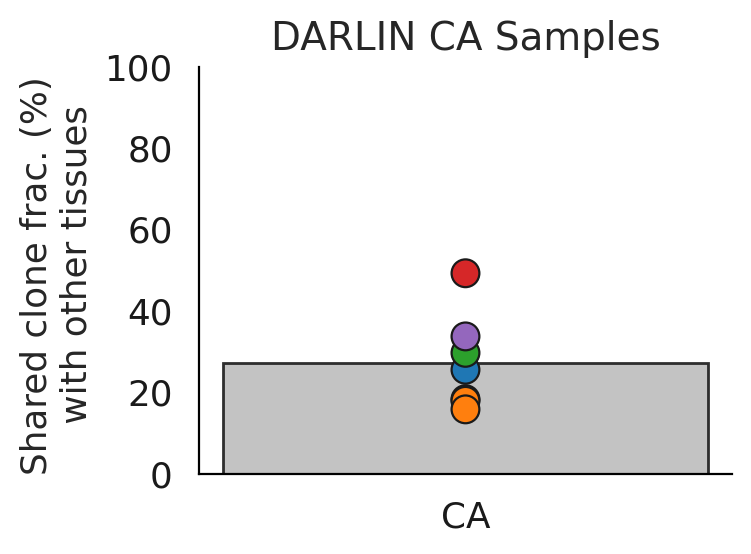

In [ ]:


cs.settings.set_figure_params(figsize=(6, 5.5))

df_pvalue_list = []

for x in df_final['stage'].unique():
    print(f"\n=== Stage: {x} ===")

    # --- Filter relevant subset ---
    df_tmp = df_final[
        (df_final['stage'] == x)
        & (df_final['min_clone_size'] == min_clone_size)
        & (df_final['allele_complexity'] == 4)
        & (df_final['read_cutoff'] == read_cutoff)
    ].copy()

    if df_tmp.empty:
        print(f" Skipping {x}: no data after filtering.")
        continue

    print(f"  → Rows after filtering: {len(df_tmp)}")
    print(f"  → Unique tissues: {df_tmp['tissue'].unique()}")
    if 'target_cell_type' in df_tmp.columns:
        print(f"  → target_cell_type values: {df_tmp['target_cell_type'].unique()}")

    # --- Clean overlap_fraction ---
    df_tmp = df_tmp.dropna(subset=['overlap_fraction'])
    if df_tmp.empty:
        print(f" No valid overlap_fraction values for {x}. Skipping stage.")
        continue

    # --- Create 'celltype_id' if missing ---
    if 'celltype_id' not in df_tmp.columns:
        unique_types = (
            df_tmp['target_cell_type'].unique()
            if 'target_cell_type' in df_tmp.columns
            else ['CA']
        )
        df_tmp['target_cell_type'] = (
            df_tmp['target_cell_type'] if 'target_cell_type' in df_tmp.columns else 'CA'
        )
        df_tmp['celltype_id'] = df_tmp['target_cell_type'].astype('category').cat.codes
        print(f"ℹ️ Generated numeric IDs for {len(unique_types)} cell type(s): {unique_types}")

    # --- Extend tissue_colors if needed ---
    unique_tissues = sorted(df_tmp['tissue'].unique())
    missing = [t for t in unique_tissues if t not in tissue_colors]
    if missing:
        print(f"Adding missing tissue colors for: {missing}")
        extra_colors = sns.color_palette('tab10', len(missing)).as_hex()
        for t, c in zip(missing, extra_colors):
            tissue_colors[t] = c

    # --- Compute p-values across groups (if meaningful) ---
    key_1 = 'target_cell_type'
    key_2 = 'overlap_fraction'
    try:
        df_pvalue_tmp = pvalue_estimation(df_tmp, key_1, key_2)
        df_pvalue_tmp['variable'] = x
        df_pvalue_list.append(df_pvalue_tmp)
    except Exception as e:
        print(f" p-value computation skipped for {x}: {e}")

    # --- Mean overlap for barplot ---
    df_tmp_1 = (
        df_tmp.groupby('celltype_id')[key_2]
        .mean()
        .reset_index()
        .sort_values('celltype_id')
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(4, 3))
    kwargs = {'alpha': 0.9, 'linewidth': 1, 'edgecolor': 'k'}

    sns.barplot(
        data=df_tmp_1,
        x='celltype_id',
        y=key_2,
        color='#bdbdbd',
        ax=ax,
        **kwargs
    )

    sns.scatterplot(
        data=df_tmp,
        x=cs.pl.rand_jitter(df_tmp['celltype_id'], 0.03),
        y='overlap_fraction',
        hue='tissue',
        s=100,
        alpha=1,
        edgecolor='k',
        palette=tissue_colors,
        ax=ax
    )

    # --- Dynamic x-axis labels ---
    xticks = sorted(df_tmp['celltype_id'].unique())
    xticklabels = sorted(df_tmp['target_cell_type'].unique())
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=0)

    ax.get_legend().remove()
    plt.ylim([0, 100])
    ylabel = (
        'Shared clone frac. (%) \n with other tissues'
        if len(unique_tissues) > 1
        else 'Shared clone frac. (%)'
    )
    plt.ylabel(ylabel)
    plt.xlabel('')

    plt.title(title_map.get(x, f'{x} samples'))
    plt.tight_layout()

    out_file = f"{paper_figure_path}/max_overlap_with_other_tissues_over_celltype_{data_des}_{x}.pdf"
    plt.savefig(out_file)
    print(f" Saved plot for {x} → {out_file}")

    display(df_tmp_1)

# --- Combine p-value summaries ---
if df_pvalue_list:
    df_pvalue = pd.concat(df_pvalue_list, ignore_index=True)
    print("\n Combined p-value summary:")
    display(df_pvalue)
else:
    print("⚠️ No p-value data was generated.")



=== Processing CA ===
📊 Avg target clone N for CA: 444.43
   Unique cell types: ['CA']
🎨 Adding missing cell type colors for: ['CA']
✅ Saved plot 1 → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/figure/max_overlap_with_other_tissues_over_mutation_num_distinguish_ref_type_CA.pdf


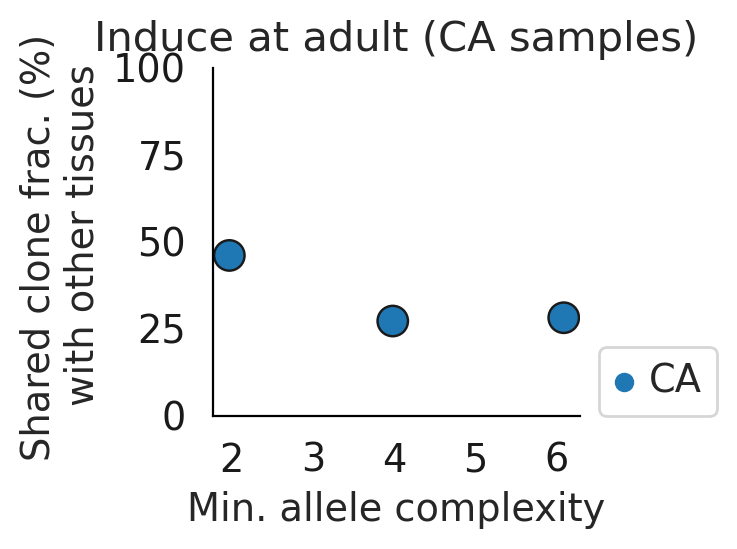

✅ Saved plot 2 → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/figure/target_clone_N_over_mutation_num_distinguish_ref_type_CA.pdf


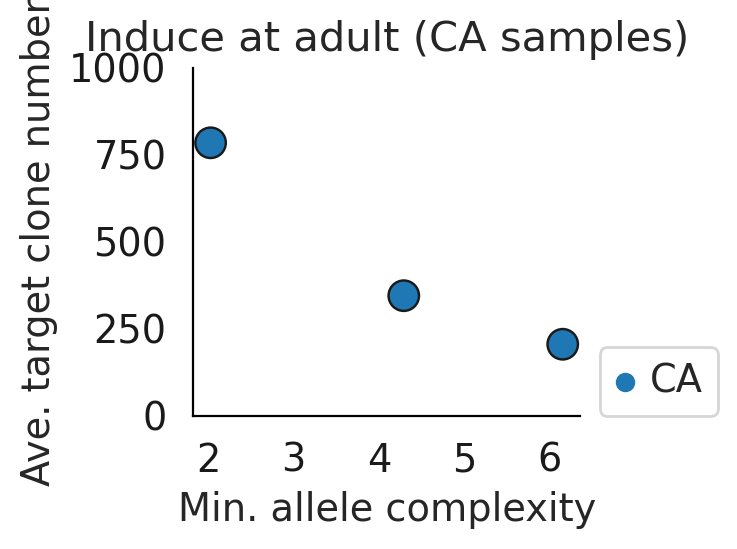

In [ ]:


cs.settings.set_figure_params(figsize=(6, 5.5), fontsize=15)

for mouse in mouse_list:
    print(f"\n=== Processing {mouse} ===")

    df_tmp = df_final[
        (df_final['allele_complexity'] <= 6)
        & (df_final['mouse'] == mouse)
        & (df_final['min_clone_size'] == min_clone_size)
        & (df_final['read_cutoff'] == read_cutoff)
    ].copy()

    if df_tmp.empty:
        print(f" No data available for {mouse}, skipping.")
        continue

    # Ensure target_cell_type exists (for CA-like datasets)
    if 'target_cell_type' not in df_tmp.columns or df_tmp['target_cell_type'].nunique() == 0:
        df_tmp['target_cell_type'] = 'CA'

    # Compute mean per complexity × cell type
    df_tmp = (
        df_tmp.groupby(['allele_complexity', 'target_cell_type'])
        .mean(numeric_only=True)
        .reset_index()
    )

    print(f" Avg target clone N for {mouse}: {df_tmp['target_clone_N'].mean():.2f}")
    print(f"   Unique cell types: {df_tmp['target_cell_type'].unique()}")

    # --- Extend color palette dynamically ---
    unique_types = sorted(df_tmp['target_cell_type'].unique())
    missing = [t for t in unique_types if t not in celltype_colors]
    if missing:
        print(f" Adding missing cell type colors for: {missing}")
        extra_colors = sns.color_palette('tab10', len(missing)).as_hex()
        for t, c in zip(missing, extra_colors):
            celltype_colors[t] = c

    # --- Plot 1: Shared clone fraction ---
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.scatterplot(
        data=df_tmp,
        x=cs.pl.rand_jitter(df_tmp['allele_complexity'], 0.05),
        y='overlap_fraction',
        hue='target_cell_type',
        s=120,
        alpha=1,
        edgecolor='k',
        palette=celltype_colors,
        ax=ax
    )

    ax.get_legend().remove()
    plt.legend(loc=[1.05, 0])
    plt.ylim([0, 100])
    plt.xticks([2, 3, 4, 5, 6], [2, 3, 4, 5, 6])
    plt.ylabel('Shared clone frac. (%) \n with other tissues')
    plt.xlabel('Min. allele complexity')
    plt.title(mouse_map_2.get(mouse, mouse))
    plt.tight_layout()

    out_path1 = f"{paper_figure_path}/max_overlap_with_other_tissues_over_mutation_num_{data_des}_{mouse}.pdf"
    plt.savefig(out_path1)
    print(f" Saved plot 1 → {out_path1}")
    plt.show()   #  Display figure inline

    # --- Plot 2: Target clone number ---
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.scatterplot(
        data=df_tmp,
        x=cs.pl.rand_jitter(df_tmp['allele_complexity'], 0.05),
        y='target_clone_N',
        hue='target_cell_type',
        s=120,
        alpha=1,
        edgecolor='k',
        palette=celltype_colors,
        ax=ax
    )

    ax.get_legend().remove()
    plt.legend(loc=[1.05, 0])
    plt.xticks([2, 3, 4, 5, 6], [2, 3, 4, 5, 6])

    if 'ylim_map' in globals() and mouse in ylim_map:
        plt.ylim([0, ylim_map[mouse]])
    else:
        plt.ylim([0, df_tmp['target_clone_N'].max() * 1.1])

    plt.ylabel('Ave. target clone number')
    plt.xlabel('Min. allele complexity')
    plt.title(mouse_map_2.get(mouse, mouse))
    plt.tight_layout()

    out_path2 = f"{paper_figure_path}/target_clone_N_over_mutation_num_{data_des}_{mouse}.pdf"
    plt.savefig(out_path2)
    print(f"Saved plot 2 → {out_path2}")
    plt.show()   #  Display second figure inline

    plt.close('all')



=== Processing CA ===
  → 1 rows aggregated by read_cutoff and target_cell_type.
✅ Saved → /scratch/ucgd/lustre-labs/yang/User/u6069192_Sai/Snakmake_pipe_lines/Darlin_org/Main_Darl/CA/DARLIN/results_cutoff_override_3/figure/max_overlap_with_other_tissues_over_readcutoff_distinguish_ref_type_Adult.pdf


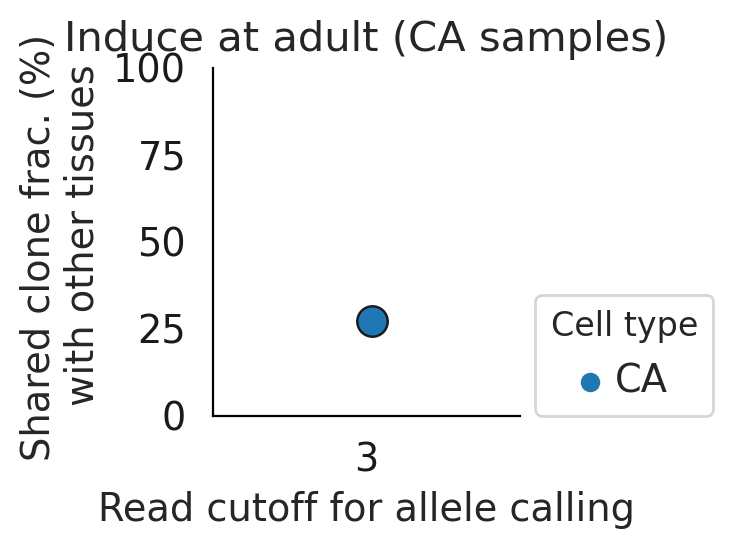

In [ ]:
# ============================================================
#   Shared clone fraction vs. read cutoff across cell types
# ============================================================

data_des = 'distinguish_ref_type'

for mouse in mouse_list:
    print(f"\n=== Processing {mouse} ===")

    # --- Filter relevant subset ---
    df_tmp = df_final[
        (df_final['min_clone_size'] == min_clone_size)
        & (df_final['mouse'] == mouse)
        & (df_final['allele_complexity'] == 4)
    ].copy()

    if df_tmp.empty:
        print(f" No data found for {mouse}, skipping.")
        continue

    # --- Ensure 'target_cell_type' exists ---
    if 'target_cell_type' not in df_tmp.columns or df_tmp['target_cell_type'].nunique() == 0:
        df_tmp['target_cell_type'] = 'CA'

    # --- Compute means ---
    key_1 = 'read_cutoff'
    key_2 = 'overlap_fraction'
    df_tmp = (
        df_tmp.groupby([key_1, 'target_cell_type'])
        .mean(numeric_only=True)
        .reset_index()
    )

    print(f"   {len(df_tmp)} rows aggregated by {key_1} and target_cell_type.")

    # --- Extend color palette dynamically ---
    unique_types = sorted(df_tmp['target_cell_type'].unique())
    missing = [t for t in unique_types if t not in celltype_colors]
    if missing:
        print(f" Adding missing colors for: {missing}")
        extra_colors = sns.color_palette('tab10', len(missing)).as_hex()
        for t, c in zip(missing, extra_colors):
            celltype_colors[t] = c

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.scatterplot(
        data=df_tmp,
        x=cs.pl.rand_jitter(df_tmp[key_1], 0.05),
        y=key_2,
        hue='target_cell_type',
        s=120,
        alpha=1,
        edgecolor='k',
        palette=celltype_colors,
        ax=ax
    )

    plt.legend(loc=[1.05, 0], title='Cell type')
    plt.ylim([0, 100])

    # dynamic xticks based on unique read_cutoff values
    xticks_sorted = sorted(df_tmp[key_1].unique())
    ax.set_xticks(xticks_sorted)
    ax.set_xticklabels([str(int(x)) for x in xticks_sorted], rotation=0)
    ax.set_xlim([min(xticks_sorted) - 0.5, max(xticks_sorted) + 0.5])

    plt.ylabel('Shared clone frac. (%) \n with other tissues')
    plt.xlabel('Read cutoff for allele calling')

    # Safe title mapping
    plt.title(mouse_map_2.get(mouse, mouse))
    plt.tight_layout()

    # Save + show
    out_path = f"{paper_figure_path}/max_overlap_with_other_tissues_over_readcutoff_{data_des}_{mouse_map.get(mouse, mouse)}.pdf"
    plt.savefig(out_path)
    print(f" Saved → {out_path}")

    plt.show()
    plt.close()


<Figure size 700x500 with 0 Axes>

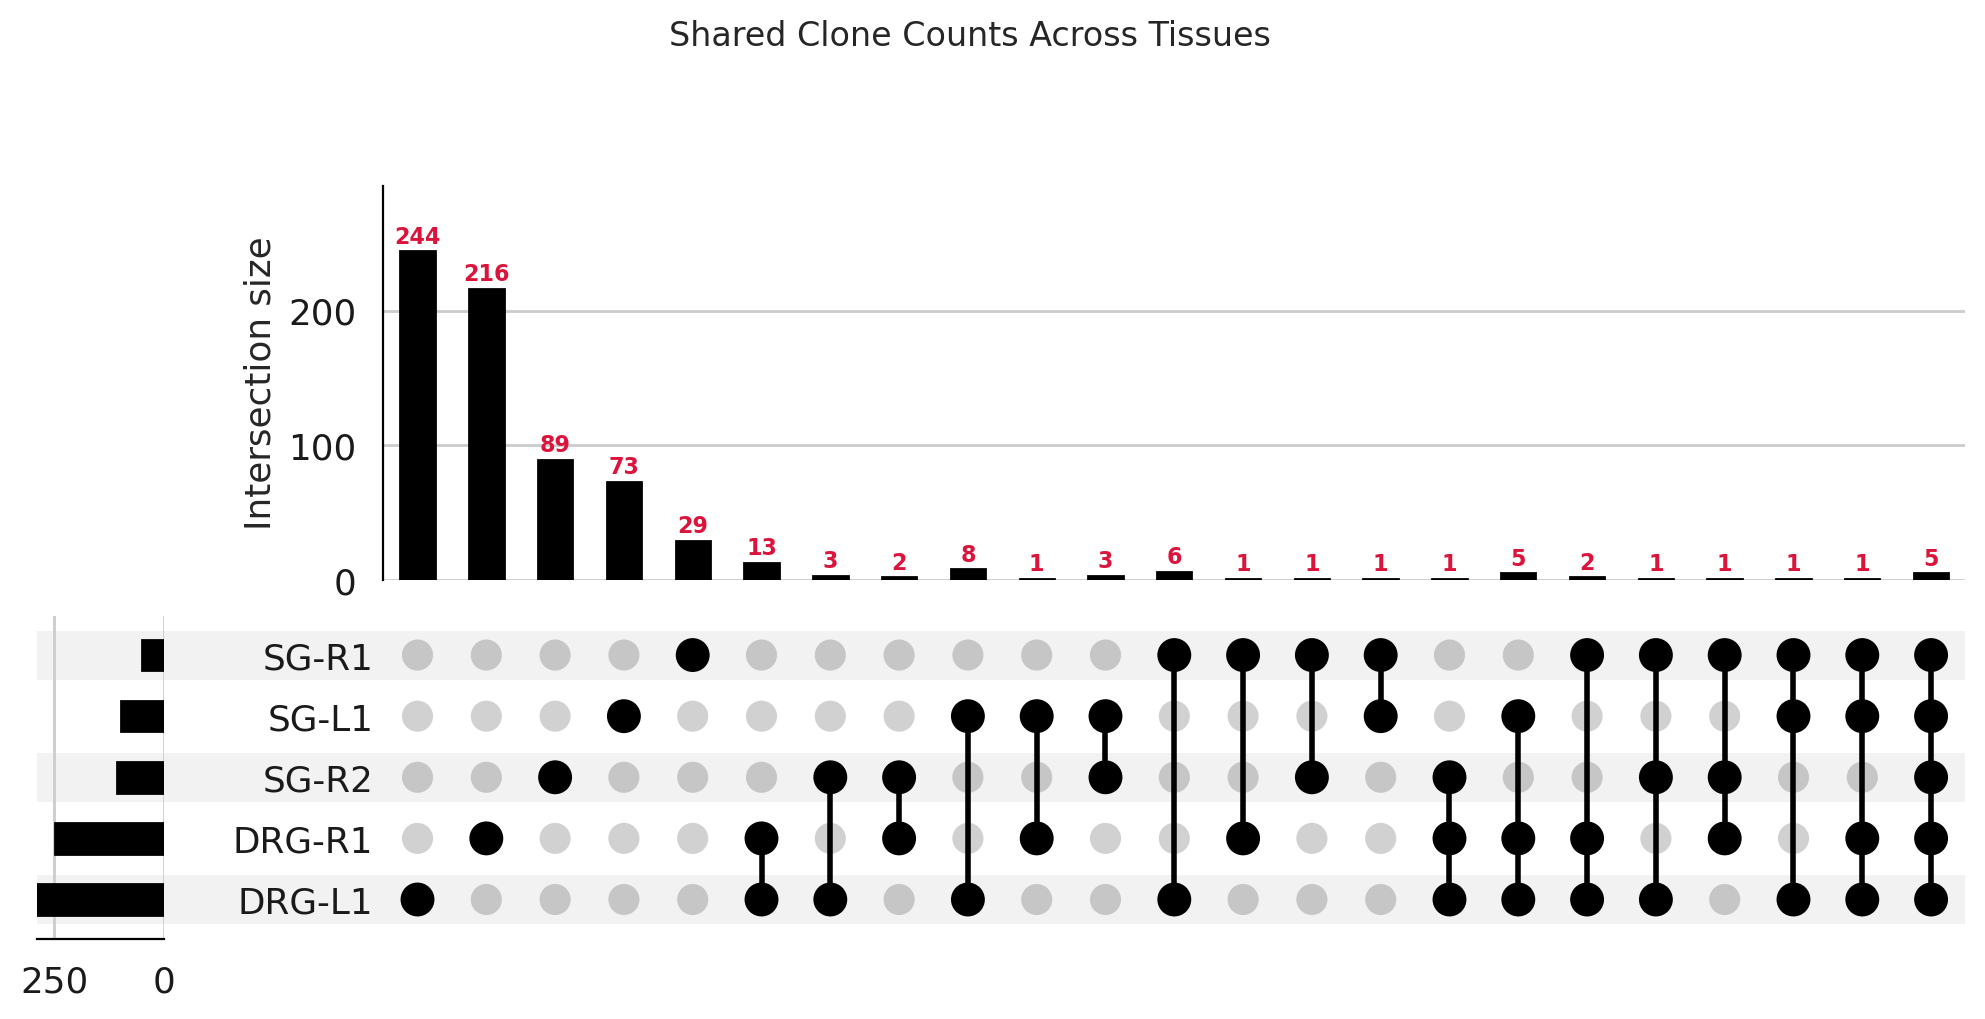

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

# === Step 1: Build binary clone × tissue matrix ===
excluded_tissues = ['DA-CA_', 'Heart-CA']

df_table = (
    df_clone_HQ_grouped
    .pivot(index='allele', columns='tissue', values='count')
    .fillna(0)
)

# Drop excluded tissues
df_table = df_table.drop(columns=excluded_tissues, errors='ignore')

# Convert to binary presence/absence
df_binary = (df_table > 0).astype(int)

# === Step 2: Build membership list for each allele ===
allele_to_samples = (
    df_binary[df_binary == 1]
    .stack()
    .reset_index()
    .groupby('allele')['tissue']
    .apply(list)
)
memberships = allele_to_samples.tolist()

# === Step 3: Generate intersection data (counts only) ===
data_upset = from_memberships(memberships)
data_upset = data_upset.groupby(level=list(range(data_upset.index.nlevels))).size()

# === Step 4: Plot annotated UpSet ===
plt.figure(figsize=(7, 5))
upset = UpSet(
    data_upset,
    sort_by='degree',
    show_counts=False,
    facecolor='black'
)

# Create plot
axes_dict = upset.plot()
ax = axes_dict.get('intersections', plt.gca())

# === Step 5: Add correctly aligned count labels ===
bars = ax.patches
vals = list(upset.intersections)  # <---- FIXED LINE

for patch, val in zip(bars, vals):
    if val > 0:
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + (0.01 * data_upset.max()),
            f"{int(val)}",
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold',
            color='crimson'
        )

# === Step 6: Adjust and polish ===
ax.set_ylim(0, data_upset.max() * 1.2)  # adds top padding for labels

plt.suptitle(
    'Shared Clone Counts Across Tissues (Excluded DA-CA_ & Heart-CA)',
    y=1.05,
    fontsize=12
)
# === Step 6: Adjust and polish ===
ax.set_ylim(0, data_upset.max() * 1.2)  # adds top padding for labels

plt.suptitle(
    'Shared Clone Counts Across Tissues',
    y=1.05,
    fontsize=12
)
plt.tight_layout()

# === Save figure BEFORE showing ===
plt.savefig("Shared_Clone_Counts_UpSet.pdf", format='pdf', dpi=300, bbox_inches='tight')

# Then display interactively
plt.show()
